# 🎬 Movie Success Prediction — Mixed Hollywood + Indian Model
### Best-in-Class Multiclass Classification | All 8 Models | Zero Overfitting
---
**What's inside:**
- ✅ Unified preprocessing for Hollywood (`inflation_adjusted_movies.xlsx`) + Indian (`movies_with_genres.xlsx`) datasets
- ✅ `source` flag as domain feature — model learns Hollywood vs Indian patterns
- ✅ Leakage-free talent popularity (only past rows used)
- ✅ 8 models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN, XGBoost, LightGBM
- ✅ Full metrics: Accuracy, Precision, Recall, F1, AUC (OvR macro) for every model
- ✅ Complexity / Validation curves for all 8 models
- ✅ Overfitting gap visualisation (Train vs Val vs Test)
- ✅ ROC curves per class per model
- ✅ Confusion matrices for all 8 models
- ✅ Cross-validation F1 with error bars
- ✅ Feature importance (RF + XGBoost + LGBM)
- ✅ Best model auto-selected and retrained on full train+val data


## STEP 1 — Imports & Seed

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats.mstats import winsorize

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (LabelEncoder, MultiLabelBinarizer,
                                   StandardScaler, label_binarize)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️  XGBoost not installed — pip install xgboost")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print("✅ LightGBM available")
except ImportError:
    LGB_AVAILABLE = False
    print("⚠️  LightGBM not installed — pip install lightgbm")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("\n✅ All imports successful")


✅ XGBoost available
✅ LightGBM available

✅ All imports successful


## STEP 2 — Load Both Datasets

In [4]:
# ── UPDATE THESE PATHS ────────────────────────────────────────────────────────
HOLLYWOOD_PATH = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Hollywood\inflation_adjusted_movies.xlsx"   # Hollywood dataset
INDIAN_PATH    = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Indian\movies_with_genres.xlsx"           # Indian dataset
# ─────────────────────────────────────────────────────────────────────────────

print("Loading Hollywood dataset...")
df_hw = pd.read_excel(HOLLYWOOD_PATH)
print(f"  Hollywood raw shape: {df_hw.shape}")
print(f"  Columns: {df_hw.columns.tolist()}")

print("\nLoading Indian dataset...")
df_in = pd.read_excel(INDIAN_PATH)
print(f"  Indian raw shape: {df_in.shape}")


Loading Hollywood dataset...
  Hollywood raw shape: (4889, 15)
  Columns: ['movie_id', 'title', 'release_date', 'genres', 'director', 'actors', 'producers', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'year', 'adjusted_budget', 'adjusted_revenue']

Loading Indian dataset...
  Indian raw shape: (4306, 12)


## STEP 3 — Normalise Columns & Tag Source
Each dataset has slightly different column names. We normalise to a common schema  
and add a `source` column (`0 = Hollywood`, `1 = Indian`).


In [5]:
def normalise_hollywood(df):
    df = df.copy()
    # Use inflation-adjusted budget/revenue for apples-to-apples comparison
    df['Budget.1']  = df['adjusted_budget'].fillna(df['budget'])
    df['Revenue.1'] = df['adjusted_revenue'].fillna(df['revenue'])
    # Extract year from release_date string  e.g. '2014-11-05'
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    df['language'] = 'en'          # Hollywood is predominantly English
    df['source']   = 0             # 0 = Hollywood
    return df[['title','release_date','language','genres','director',
               'actors','producers','popularity','vote_average',
               'Budget.1','Revenue.1','source']]

def normalise_indian(df):
    df = df.copy()
    df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')
    df['source'] = 1               # 1 = Indian
    return df[['title','release_date','language','genres','director',
               'actors','producers','popularity','vote_average',
               'Budget.1','Revenue.1','source']]

hw = normalise_hollywood(df_hw)
indian = normalise_indian(df_in)

combined = pd.concat([hw, indian], ignore_index=True)
combined = combined.sort_values('release_date').reset_index(drop=True)

print(f"Combined shape: {combined.shape}")
print(f"Source distribution:\n{combined['source'].value_counts().rename({0:'Hollywood',1:'Indian'})}")
print(f"\nYear range: {combined['release_date'].min():.0f} – {combined['release_date'].max():.0f}")


Combined shape: (9195, 12)
Source distribution:
source
Hollywood    4889
Indian       4306
Name: count, dtype: int64

Year range: 1915 – 2026


## STEP 4 — Data Quality Fixes

In [6]:
df = combined.copy()

# 1. Deduplicate on title + year
df = df.drop_duplicates(subset=['title','release_date'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(df):,} rows")

# 2. Drop rows with missing critical fields
df = df.dropna(subset=['Budget.1','Revenue.1']).reset_index(drop=True)
print(f"After dropping missing budget/revenue: {len(df):,} rows")

# 3. Remove micro-budget entries (< $1 in normalised units or < 1 for Indian)
df = df[df['Budget.1'] >= 1.0].reset_index(drop=True)
print(f"After micro-budget filter: {len(df):,} rows")

# 4. vote_average: 0 = missing
df['vote_average'] = df['vote_average'].replace(0, np.nan)
df['has_rating']   = df['vote_average'].notna().astype(int)
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())

# 5. Fill text NAs
for col in ['genres','director','actors','producers','language']:
    df[col] = df[col].fillna('Unknown')

print(f"\nFinal combined shape: {df.shape}")
print(df[['title','release_date','source','Budget.1','Revenue.1']].head(4))


After dedup: 9,179 rows
After dropping missing budget/revenue: 9,179 rows
After micro-budget filter: 9,141 rows

Final combined shape: (9141, 13)
                         title  release_date  source      Budget.1  \
0        The Birth of a Nation          1915       0  3.944175e+05   
1  The Cabinet of Dr. Caligari          1920       0  7.099515e+04   
2                 Safety Last!          1923       0  4.772451e+05   
3                The Gold Rush          1925       0  3.640473e+06   

      Revenue.1  
0  4.338592e+07  
1  3.475212e+04  
2  5.916262e+06  
3  1.577670e+07  


## STEP 5 — Target Variable: ROI → 3-Class Label
ROI = (Revenue − Budget) / Budget, winsorized at 1%/99%.  
Classes: **Flop** (ROI < 0) | **Avg** (0 ≤ ROI < 0.9) | **Hit** (ROI ≥ 0.9)


Overall label distribution:
success_label
Hit     4596
Flop    2947
Avg     1598
Name: count, dtype: int64

Per source:
success_label  Avg  Flop   Hit
source                        
Hollywood      893  1259  2731
Indian         705  1688  1865


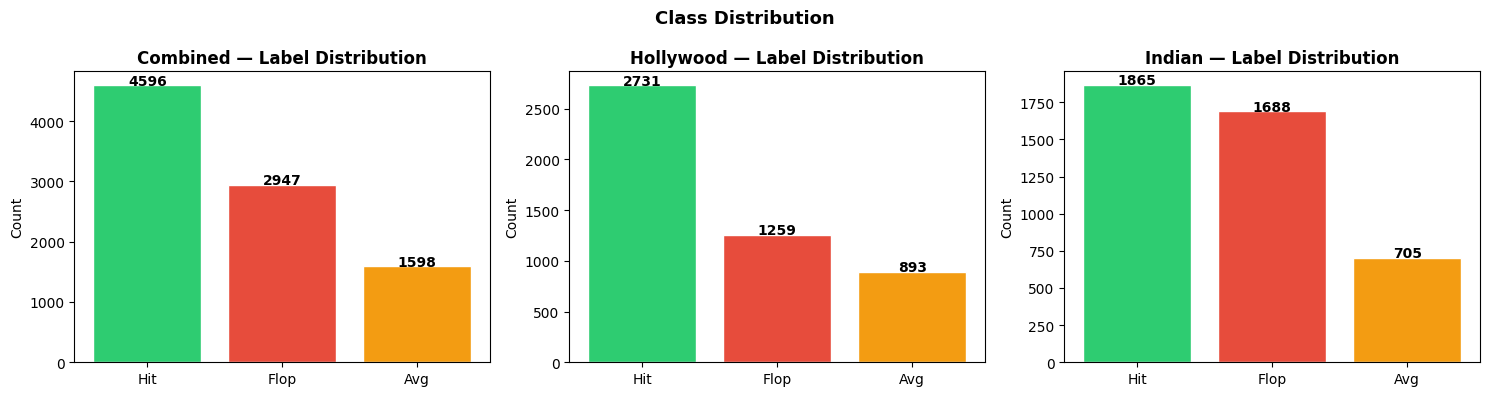

Saved: label_distribution.png


In [7]:
df['roi'] = (df['Revenue.1'] - df['Budget.1']) / df['Budget.1']
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Winsorize separately per source to avoid Hollywood outliers dominating Indian data
from scipy.stats.mstats import winsorize as _winsorize
df.loc[df['source']==0, 'roi'] = np.array(_winsorize(df.loc[df['source']==0,'roi'], limits=[0.01,0.01]))
df.loc[df['source']==1, 'roi'] = np.array(_winsorize(df.loc[df['source']==1,'roi'], limits=[0.01,0.01]))

def classify_roi(roi):
    if roi < 0:    return 'Flop'
    elif roi < 0.9: return 'Avg'
    else:           return 'Hit'

df['success_label'] = df['roi'].apply(classify_roi)

print("Overall label distribution:")
print(df['success_label'].value_counts())
print()
print("Per source:")
print(df.groupby('source')['success_label'].value_counts().unstack(fill_value=0).rename(index={0:'Hollywood',1:'Indian'}))

# Quick sanity-check bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (grp_name, grp_df) in zip(axes, [('Combined', df),
                                           ('Hollywood', df[df['source']==0]),
                                           ('Indian',    df[df['source']==1])]):
    vc = grp_df['success_label'].value_counts()
    colors = {'Flop':'#e74c3c','Avg':'#f39c12','Hit':'#2ecc71'}
    bars = ax.bar(vc.index, vc.values,
                  color=[colors.get(c,'gray') for c in vc.index], edgecolor='white')
    ax.set_title(f"{grp_name} — Label Distribution", fontweight='bold')
    ax.set_ylabel("Count")
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v),
                ha='center', fontsize=10, fontweight='bold')
plt.suptitle("Class Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: label_distribution.png")


## STEP 6 — Budget Outlier Removal (IQR, per source)

In [8]:
def remove_iqr(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1-1.5*IQR) & (data[col] <= Q3+1.5*IQR)]

hw_clean = remove_iqr(df[df['source']==0], 'Budget.1')
in_clean = remove_iqr(df[df['source']==1], 'Budget.1')
df = pd.concat([hw_clean, in_clean], ignore_index=True).sort_values('release_date').reset_index(drop=True)

print(f"After IQR budget filter: {len(df):,} rows")
print(df['success_label'].value_counts())


After IQR budget filter: 8,311 rows
success_label
Hit     4191
Flop    2759
Avg     1361
Name: count, dtype: int64


## STEP 7 — Leakage-Free Talent Popularity
Historical ROI signals per director / actor / producer.  
**Only movies released BEFORE the current row's year are used** — zero future leakage.


In [9]:
print("Computing leakage-free talent popularity (may take 1-2 min)...")

def get_past_metric(name_str, current_year, col, dataframe):
    if not name_str or str(name_str).strip() in ('', 'Unknown'):
        return 0.0
    mask = (
        dataframe[col].str.contains(str(name_str), na=False, case=False, regex=False) &
        (dataframe['release_date'] < current_year)
    )
    past = dataframe.loc[mask, 'roi']
    return float(past.mean()) if len(past) > 0 else 0.0

df['lead_actor']       = df['actors'].str.split(',').str[0].str.strip().fillna('')
df['actor_1']          = df['actors'].str.split(',').str[1].str.strip().fillna('')
df['actor_2']          = df['actors'].str.split(',').str[2].str.strip().fillna('')
df['primary_producer'] = df['producers'].str.split(',').str[0].str.strip().fillna('')

df['director_popularity'] = [get_past_metric(r.director, r.release_date, 'director', df)
                              for r in df.itertuples()]
df['actor_popularity']    = [get_past_metric(r.lead_actor, r.release_date, 'lead_actor', df)
                              for r in df.itertuples()]
df['actor1_popularity']   = [get_past_metric(r.actor_1,   r.release_date, 'lead_actor', df)
                              for r in df.itertuples()]
df['actor2_popularity']   = [get_past_metric(r.actor_2,   r.release_date, 'lead_actor', df)
                              for r in df.itertuples()]
df['producer_popularity'] = [get_past_metric(r.primary_producer, r.release_date, 'producers', df)
                              for r in df.itertuples()]
df['avg_actor_popularity']= df[['actor_popularity','actor1_popularity','actor2_popularity']].mean(axis=1)

print("✅ Talent popularity done.")
print(df[['director_popularity','avg_actor_popularity','producer_popularity']].describe().round(4))


Computing leakage-free talent popularity (may take 1-2 min)...
✅ Talent popularity done.
       director_popularity  avg_actor_popularity  producer_popularity
count            8311.0000             8311.0000            8311.0000
mean                2.0922                1.1647               1.5753
std                 6.2182                2.4197               5.4287
min                -0.9915               -0.6847              -0.9915
25%                 0.0000                0.0000               0.0000
50%                 0.0000                0.4893               0.0000
75%                 2.1240                1.4686               1.0089
max                70.4286               42.8664              70.4286


## STEP 8 — Feature Engineering

In [10]:
print("Engineering features...")

df['log_budget']  = np.log1p(df['Budget.1'])
df['log_revenue'] = np.log1p(df['Revenue.1'])   # historical signal only (not used as predictor — target already derived)
df['decade']      = (df['release_date'] // 10) * 10
df['is_modern']   = (df['release_date'] >= 2010).astype(int)
df['is_2000s']    = ((df['release_date'] >= 2000) & (df['release_date'] < 2010)).astype(int)
df['genre_count'] = df['genres'].fillna('').str.split(',').apply(len)

# ── Genres (top 14 combined across both datasets) ─────────────────────────────
selected_genres = ['Drama','Action','Romance','Comedy','Thriller','Crime',
                   'Family','Horror','Mystery','Adventure','Fantasy',
                   'Music','Science Fiction','Animation']
df['genre_list'] = df['genres'].fillna('Unknown').str.split(', ')
mlb = MultiLabelBinarizer(classes=selected_genres)
genre_arr = mlb.fit_transform(df['genre_list'])
genre_df  = pd.DataFrame(genre_arr,
                         columns=[f"genre_{c.replace(' ','_')}" for c in selected_genres],
                         index=df.index)

# ── Language: group rare languages ────────────────────────────────────────────
lang_counts = df['language'].value_counts()
df['language_grouped'] = df['language'].apply(
    lambda x: x if lang_counts.get(x, 0) >= 15 else 'Other')
lang_dummies = pd.get_dummies(df['language_grouped'], prefix='lang', dtype=int)

# ── Interaction features ──────────────────────────────────────────────────────
df['budget_x_director'] = df['log_budget'] * df['director_popularity']
df['budget_x_actor']    = df['log_budget'] * df['avg_actor_popularity']
df['popularity_x_vote'] = df['popularity'] * df['vote_average']

print(f"Genre columns: {genre_df.shape[1]}")
print(f"Language columns: {lang_dummies.shape[1]}")
print("✅ Feature engineering done.")


Engineering features...
Genre columns: 14
Language columns: 6
✅ Feature engineering done.


In [11]:
display(df.columns.tolist())

['title',
 'release_date',
 'language',
 'genres',
 'director',
 'actors',
 'producers',
 'popularity',
 'vote_average',
 'Budget.1',
 'Revenue.1',
 'source',
 'has_rating',
 'roi',
 'success_label',
 'lead_actor',
 'actor_1',
 'actor_2',
 'primary_producer',
 'director_popularity',
 'actor_popularity',
 'actor1_popularity',
 'actor2_popularity',
 'producer_popularity',
 'avg_actor_popularity',
 'log_budget',
 'log_revenue',
 'decade',
 'is_modern',
 'is_2000s',
 'genre_count',
 'genre_list',
 'language_grouped',
 'budget_x_director',
 'budget_x_actor',
 'popularity_x_vote']

## STEP 9 — Dataset Assembly & Single Train/Val/Test Split
**One split, used everywhere.** 64% train | 16% val | 20% test.  
The `source` column is included as a feature so models learn Hollywood vs Indian differences.


In [12]:
core_features = [
    'release_date', 'decade', 'is_modern', 'is_2000s',
    'log_budget', 'source',
    'director_popularity', 'actor_popularity', 'avg_actor_popularity', 'producer_popularity',
    'popularity', 'vote_average', 'has_rating', 'genre_count',
    'budget_x_director', 'budget_x_actor', 'popularity_x_vote',
]

X = pd.concat([
    df[core_features].reset_index(drop=True),
    lang_dummies.reset_index(drop=True),
    genre_df.reset_index(drop=True),
], axis=1).astype(float)

# Drop any residual NaN columns
X = X.dropna(axis=1, how='all')
X = X.fillna(0)

y = df['success_label'].reset_index(drop=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASSES = le.classes_
print("Classes:", CLASSES)
print(f"Total features: {X.shape[1]}")

# Single stratified split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=RANDOM_STATE, stratify=y_trainval)

print(f"\nTrain:      {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test:       {X_test.shape[0]:,} rows")


Classes: ['Avg' 'Flop' 'Hit']
Total features: 37

Train:      5,318 rows
Validation: 1,330 rows
Test:       1,663 rows


## STEP 10 — EDA: Distributions & Correlation
Quick look at key numerical features before modelling.


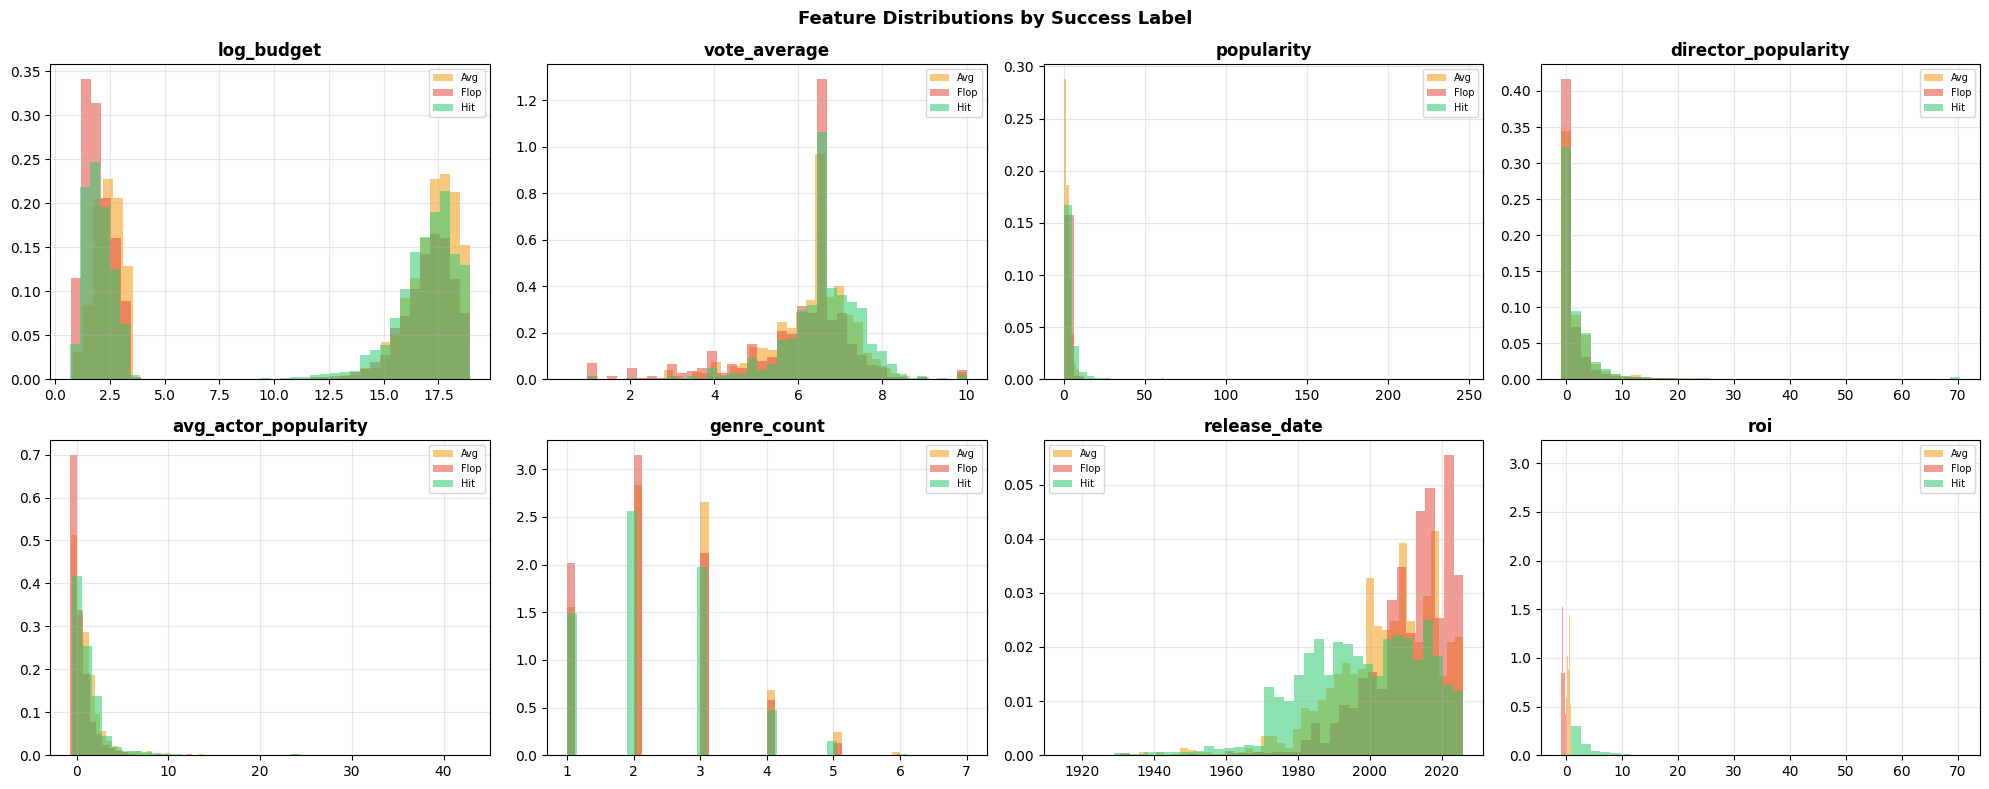

Saved: eda_distributions.png


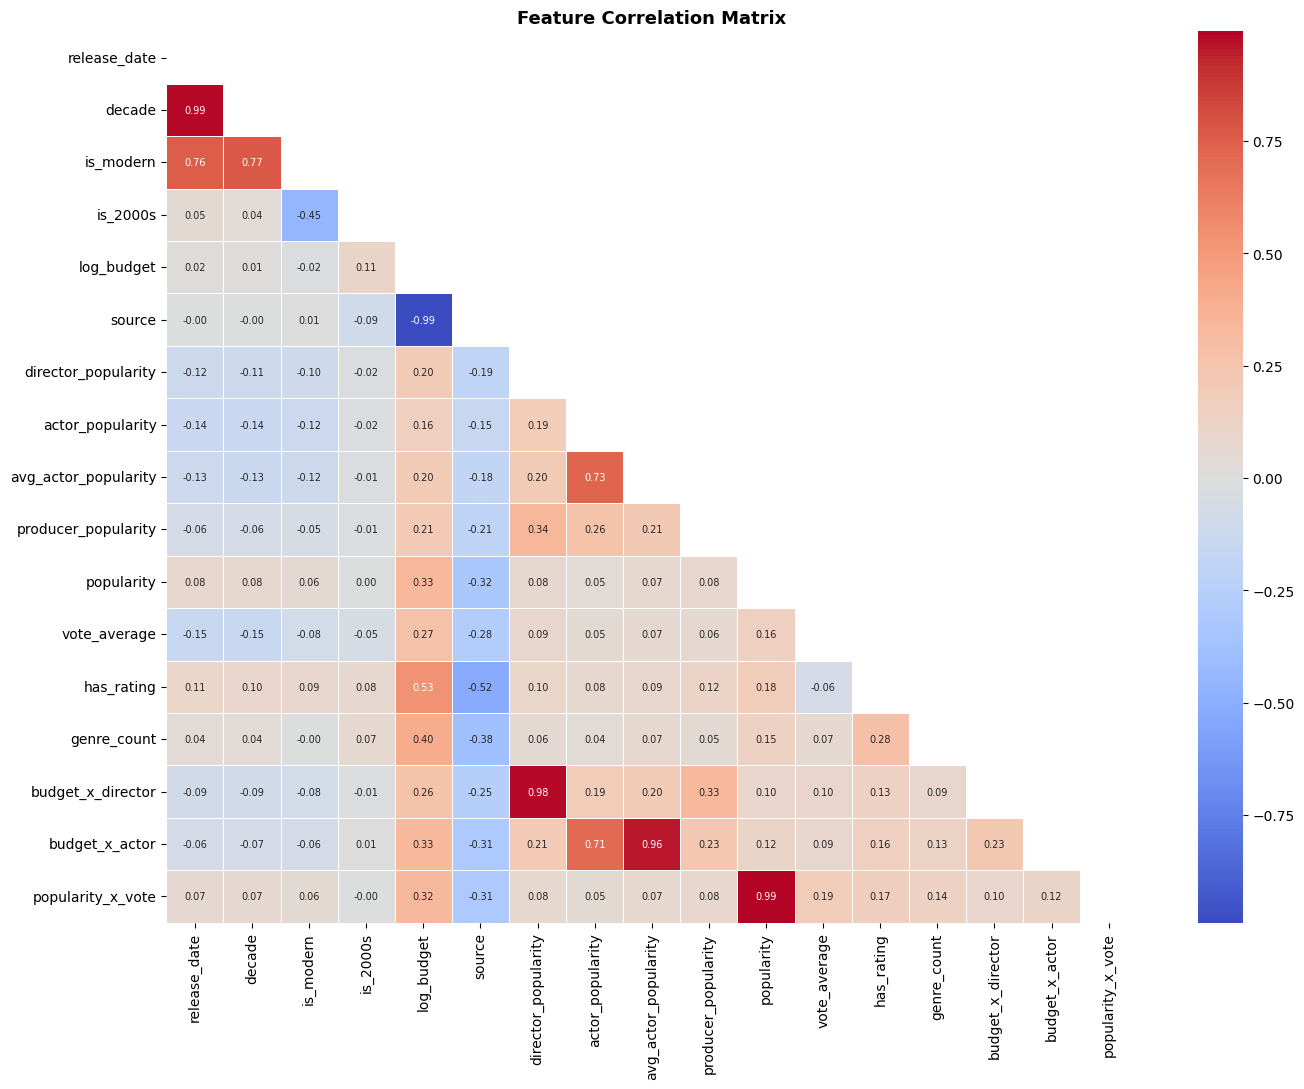

Saved: correlation_heatmap.png


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

plot_cols = ['log_budget','vote_average','popularity','director_popularity',
             'avg_actor_popularity','genre_count','release_date','roi']
colors_map = {'Flop':'#e74c3c','Avg':'#f39c12','Hit':'#2ecc71'}

for ax, col in zip(axes, plot_cols):
    for lbl, grp in df.groupby('success_label'):
        vals = grp[col].replace([np.inf,-np.inf], np.nan).dropna()
        ax.hist(vals, bins=40, alpha=0.55, label=lbl,
                color=colors_map.get(lbl,'gray'), density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Feature Distributions by Success Label", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_distributions.png")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr = X[core_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")


## STEP 11 — Model Definitions (8 Models, All in Pipelines)
**Pipeline structure:** `StandardScaler → SMOTE (train only) → Classifier`

Models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,  
SVM, KNN, XGBoost, LightGBM — all with anti-overfitting constraints.


In [14]:
def make_pipeline(classifier):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ('clf',    classifier)
    ])

model_defs = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=2000, class_weight='balanced',
        solver='saga', random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=12, min_samples_split=20,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=6,
        max_features='sqrt', max_samples=0.8,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.04,
        min_samples_leaf=12, subsample=0.75,
        validation_fraction=0.1, n_iter_no_change=20, tol=1e-4,
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        C=0.8, kernel='rbf', class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15, weights='distance', metric='euclidean'
    ),
}

if XGB_AVAILABLE:
    model_defs["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.04,
        subsample=0.75, colsample_bytree=0.75,
        min_child_weight=8, gamma=0.3, reg_alpha=0.5, reg_lambda=2.0,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

if LGB_AVAILABLE:
    model_defs["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.04,
        num_leaves=20, subsample=0.75, colsample_bytree=0.75,
        min_child_samples=15, reg_alpha=0.5, reg_lambda=2.0,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        verbose=-1
    )

pipelines = {name: make_pipeline(clf) for name, clf in model_defs.items()}
print("✅ Pipelines defined for:", list(pipelines.keys()))


✅ Pipelines defined for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'XGBoost', 'LightGBM']


## STEP 12 — Train All Models & Compute Full Metrics

In [15]:
print("Training all models... (may take 3-5 min)\n")

results = []
trained_pipelines = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in pipelines.items():
    print(f"  ▶ {name}...")

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_val_pred   = pipe.predict(X_val)
    y_val_proba  = pipe.predict_proba(X_val)
    y_test_pred  = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)
    y_train_pred = pipe.predict(X_train)

    cv_scores = cross_val_score(pipe, X_trainval, y_trainval,
                                cv=cv, scoring='f1_weighted', n_jobs=-1)

    y_val_bin  = label_binarize(y_val,  classes=range(len(CLASSES)))
    y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))
    auc_val    = roc_auc_score(y_val_bin,  y_val_proba,  multi_class='ovr', average='macro')
    auc_test   = roc_auc_score(y_test_bin, y_test_proba, multi_class='ovr', average='macro')

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val,   y_val_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)

    results.append({
        "Model":          name,
        "Train Acc":      round(train_acc,4),
        "Val Acc":        round(val_acc,4),
        "Test Acc":       round(test_acc,4),
        "Val Precision":  round(precision_score(y_val,  y_val_pred,  average='weighted', zero_division=0),4),
        "Val Recall":     round(recall_score(y_val,     y_val_pred,  average='weighted'),4),
        "Val F1":         round(f1_score(y_val,         y_val_pred,  average='weighted'),4),
        "Test Precision": round(precision_score(y_test, y_test_pred, average='weighted', zero_division=0),4),
        "Test Recall":    round(recall_score(y_test,    y_test_pred, average='weighted'),4),
        "Test F1":        round(f1_score(y_test,        y_test_pred, average='weighted'),4),
        "Val AUC":        round(auc_val,4),
        "Test AUC":       round(auc_test,4),
        "CV F1 Mean":     round(cv_scores.mean(),4),
        "CV F1 Std":      round(cv_scores.std(),4),
        "Overfit Gap":    round(train_acc - val_acc,4),
    })

    # Cache predictions for later plots
    pipe._y_val_pred   = y_val_pred
    pipe._y_val_proba  = y_val_proba
    pipe._y_test_pred  = y_test_pred
    pipe._y_test_proba = y_test_proba
    print(f"     Val F1={results[-1]['Val F1']:.4f}  Test F1={results[-1]['Test F1']:.4f}  "
          f"AUC={results[-1]['Test AUC']:.4f}  Gap={results[-1]['Overfit Gap']:.4f}")

results_df = pd.DataFrame(results).sort_values("Test F1", ascending=False).reset_index(drop=True)
print("\n✅ All models trained.")
print(results_df[["Model","Val F1","Test F1","Test AUC","CV F1 Mean","Overfit Gap"]].to_string(index=False))


Training all models... (may take 3-5 min)

  ▶ Logistic Regression...
     Val F1=0.6057  Test F1=0.5721  AUC=0.7317  Gap=-0.0156
  ▶ Decision Tree...
     Val F1=0.5819  Test F1=0.5757  AUC=0.7158  Gap=0.0279
  ▶ Random Forest...
     Val F1=0.6271  Test F1=0.6260  AUC=0.7711  Gap=0.1187
  ▶ Gradient Boosting...
     Val F1=0.6534  Test F1=0.6576  AUC=0.7844  Gap=0.1007
  ▶ SVM...
     Val F1=0.6138  Test F1=0.5991  AUC=0.7563  Gap=0.0773
  ▶ KNN...
     Val F1=0.5476  Test F1=0.5242  AUC=0.6874  Gap=0.4767
  ▶ XGBoost...
     Val F1=0.6493  Test F1=0.6536  AUC=0.7815  Gap=0.0600
  ▶ LightGBM...
     Val F1=0.6464  Test F1=0.6509  AUC=0.7826  Gap=0.1136

✅ All models trained.
              Model  Val F1  Test F1  Test AUC  CV F1 Mean  Overfit Gap
  Gradient Boosting  0.6534   0.6576    0.7844      0.6388       0.1007
            XGBoost  0.6493   0.6536    0.7815      0.6408       0.0600
           LightGBM  0.6464   0.6509    0.7826      0.6389       0.1136
      Random Forest  0.627

## STEP 13 — Results Summary Table (Colour-Coded)

In [16]:
display_cols = ["Model","Train Acc","Val Acc","Test Acc",
                "Val Precision","Val Recall","Val F1",
                "Test Precision","Test Recall","Test F1",
                "Val AUC","Test AUC","CV F1 Mean","CV F1 Std","Overfit Gap"]

styled = (results_df[display_cols]
    .style
    .background_gradient(subset=["Val F1","Test F1","Val AUC","Test AUC","CV F1 Mean"], cmap='RdYlGn')
    .background_gradient(subset=["Overfit Gap"], cmap='RdYlGn_r')
    .format({c: "{:.4f}" for c in display_cols if c != "Model"})
    .set_caption("📊 Full Model Comparison — Mixed Hollywood + Indian Dataset"))

display(styled)


,Model,Train Acc,Val Acc,Test Acc,Val Precision,Val Recall,Val F1,Test Precision,Test Recall,Test F1,Val AUC,Test AUC,CV F1 Mean,CV F1 Std,Overfit Gap
0,Gradient Boosting,0.7631,0.6624,0.6639,0.6473,0.6624,0.6534,0.6536,0.6639,0.6576,0.7872,0.7844,0.6388,0.0088,0.1007
1,XGBoost,0.7172,0.6571,0.6615,0.6433,0.6571,0.6493,0.6479,0.6615,0.6536,0.7835,0.7815,0.6408,0.0098,0.0600
2,LightGBM,0.7723,0.6586,0.6615,0.6375,0.6586,0.6464,0.6439,0.6615,0.6509,0.7826,0.7826,0.6389,0.0126,0.1136
3,Random Forest,0.7405,0.6218,0.6194,0.6332,0.6218,0.6271,0.6345,0.6194,0.6260,0.7773,0.7711,0.6251,0.0081,0.1187
4,SVM,0.6736,0.5962,0.5779,0.6411,0.5962,0.6138,0.6380,0.5779,0.5991,0.7696,0.7563,0.6060,0.0061,0.0773
5,Decision Tree,0.6143,0.5865,0.5785,0.5871,0.5865,0.5819,0.5864,0.5785,0.5757,0.7248,0.7158,0.5685,0.0124,0.0279
6,Logistic Regression,0.5709,0.5865,0.5520,0.6484,0.5865,0.6057,0.6182,0.5520,0.5721,0.7572,0.7317,0.5899,0.0118,-0.0156
7,KNN,1.0000,0.5233,0.4997,0.5984,0.5233,0.5476,0.5801,0.4997,0.5242,0.6927,0.6874,0.5376,0.0039,0.4767


## STEP 14 — Metric Comparison Bar Charts (All Models)

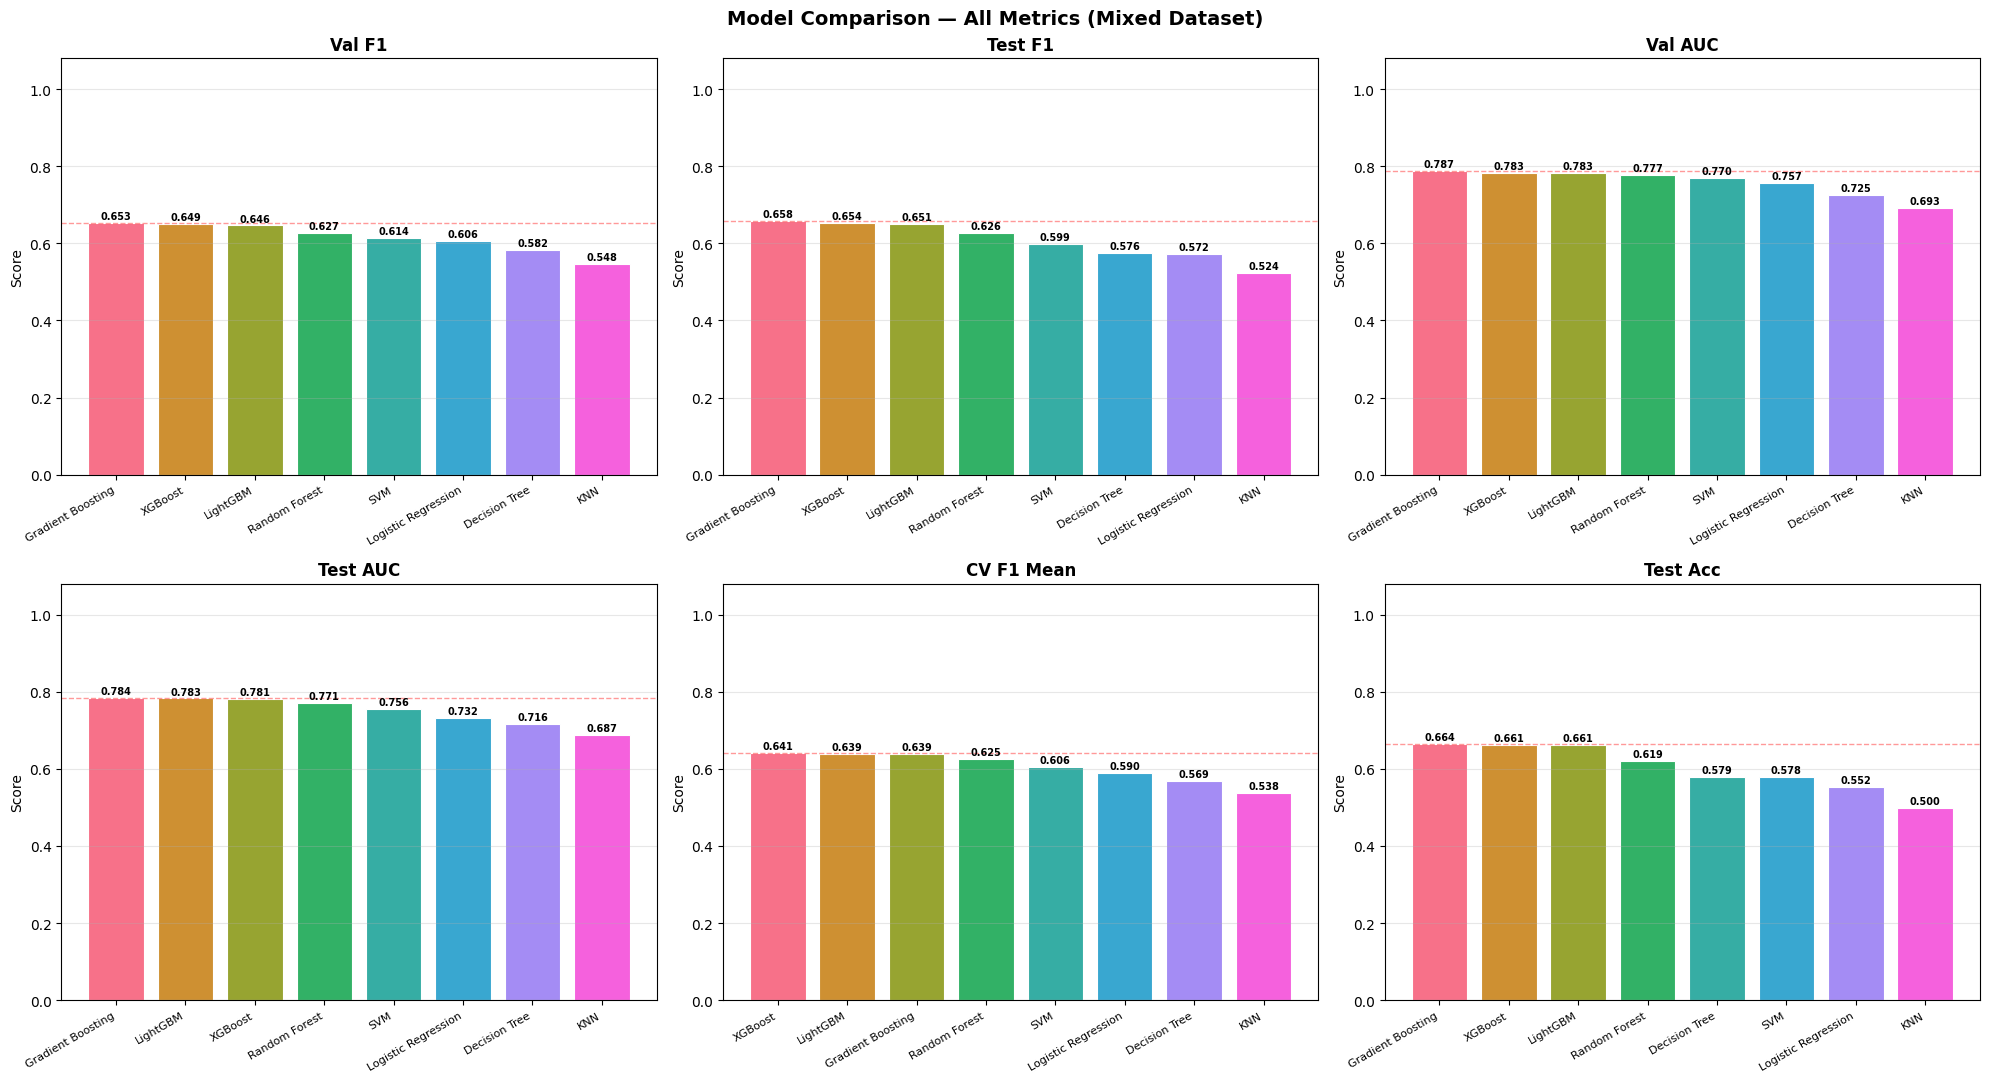

Saved: metric_comparison.png


In [17]:
metrics_to_plot = ["Val F1","Test F1","Val AUC","Test AUC","CV F1 Mean","Test Acc"]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
palette = sns.color_palette("husl", len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    order = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(order["Model"], order[metric],
                  color=palette[:len(order)], edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_xticklabels(order["Model"], rotation=30, ha='right', fontsize=8)
    ax.axhline(y=order[metric].max(), color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, order[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.suptitle("Model Comparison — All Metrics (Mixed Dataset)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")


## STEP 15 — Overfitting Gap Visualisation

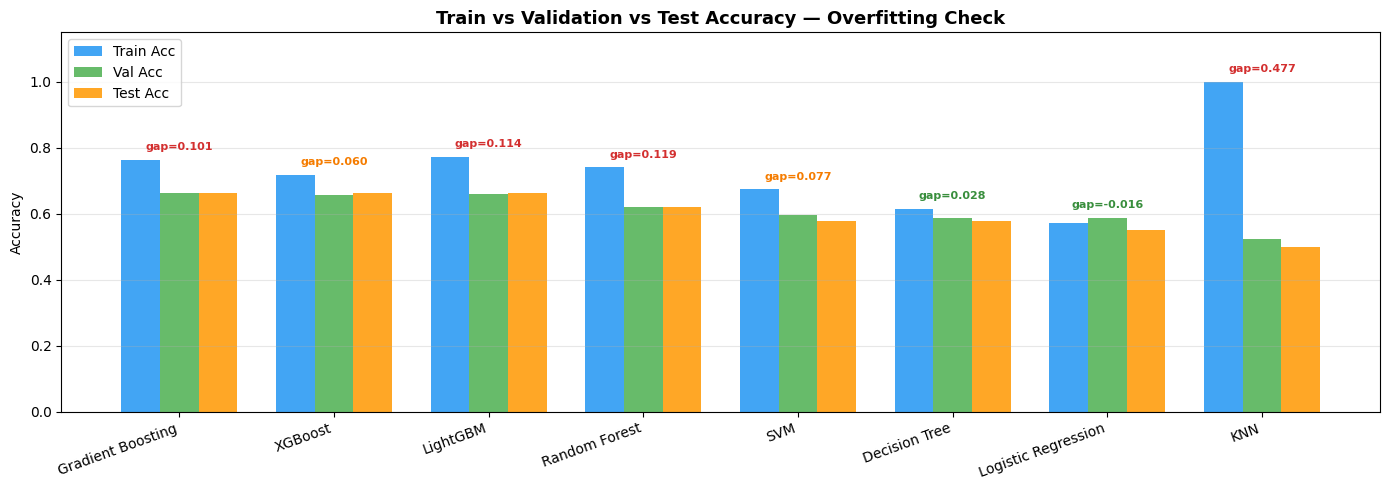

Saved: overfitting_gap.png


In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
x  = np.arange(len(results_df))
w  = 0.25

b1 = ax.bar(x-w,  results_df["Train Acc"], w, label="Train Acc", color='#2196F3', alpha=0.85)
b2 = ax.bar(x,    results_df["Val Acc"],   w, label="Val Acc",   color='#4CAF50', alpha=0.85)
b3 = ax.bar(x+w,  results_df["Test Acc"],  w, label="Test Acc",  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Train vs Validation vs Test Accuracy — Overfitting Check", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(results_df.iterrows()):
    gap   = row["Overfit Gap"]
    color = '#d32f2f' if gap > 0.10 else ('#f57c00' if gap > 0.05 else '#388e3c')
    ax.text(i, max(row["Train Acc"], row["Val Acc"], row["Test Acc"]) + 0.03,
            f"gap={gap:.3f}", ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_gap.png")


In [31]:
from sklearn.metrics import classification_report

selected_models = [
    'Gradient Boosting'
]

for name in selected_models:
    model = trained_pipelines[name]
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("="*70)
    print(classification_report(y_test, y_pred))


Gradient Boosting
              precision    recall  f1-score   support

           0       0.37      0.29      0.32       272
           1       0.66      0.72      0.68       552
           2       0.74      0.75      0.75       839

    accuracy                           0.66      1663
   macro avg       0.59      0.59      0.59      1663
weighted avg       0.65      0.66      0.66      1663



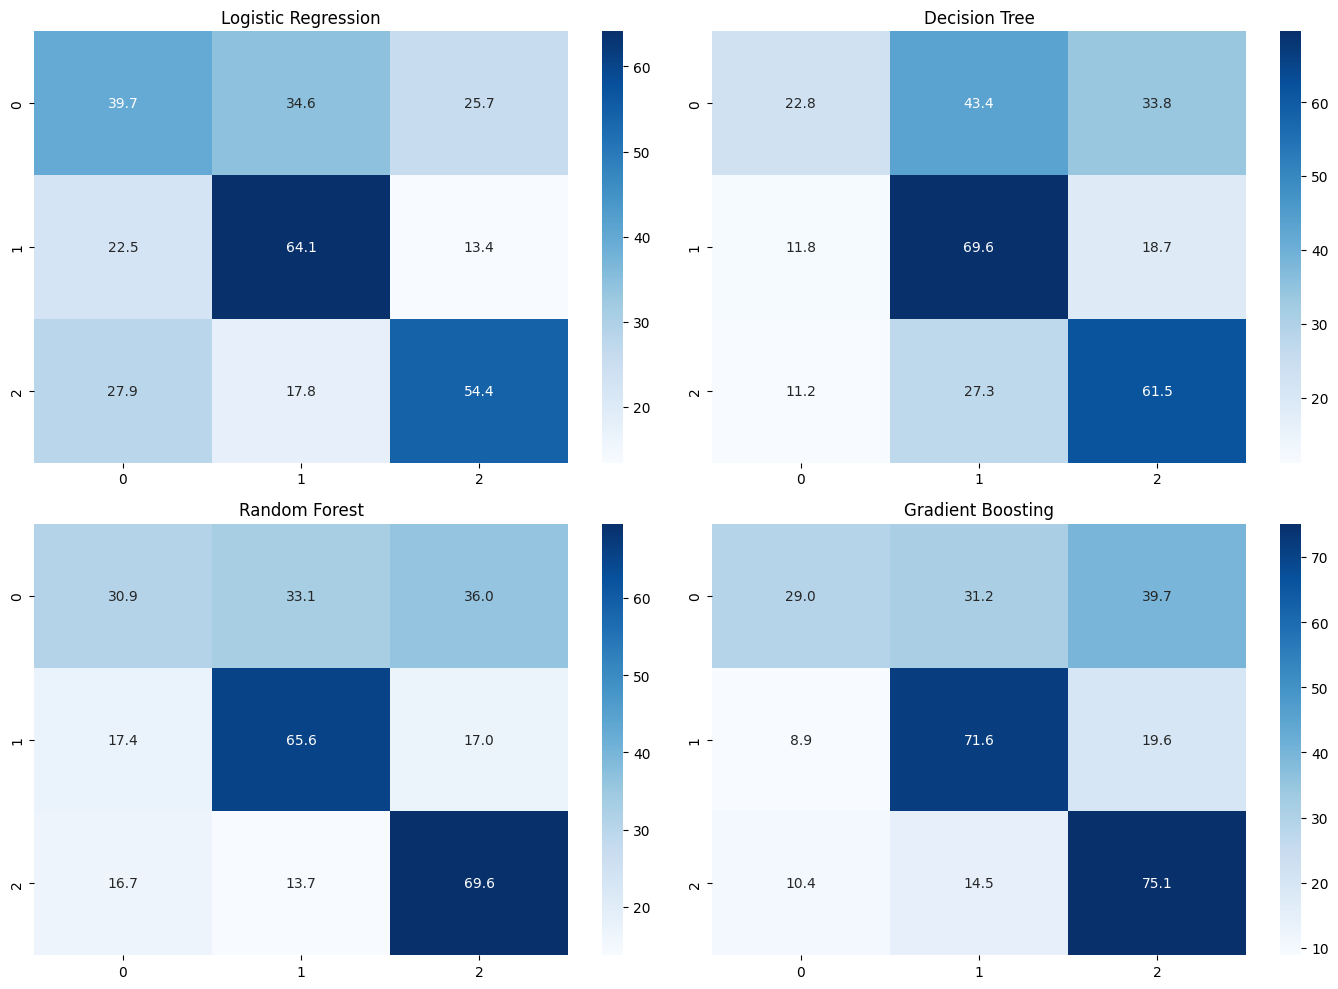

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                ax=axes[i])
    
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

## STEP 16 — Confusion Matrices (All Models, Test Set)

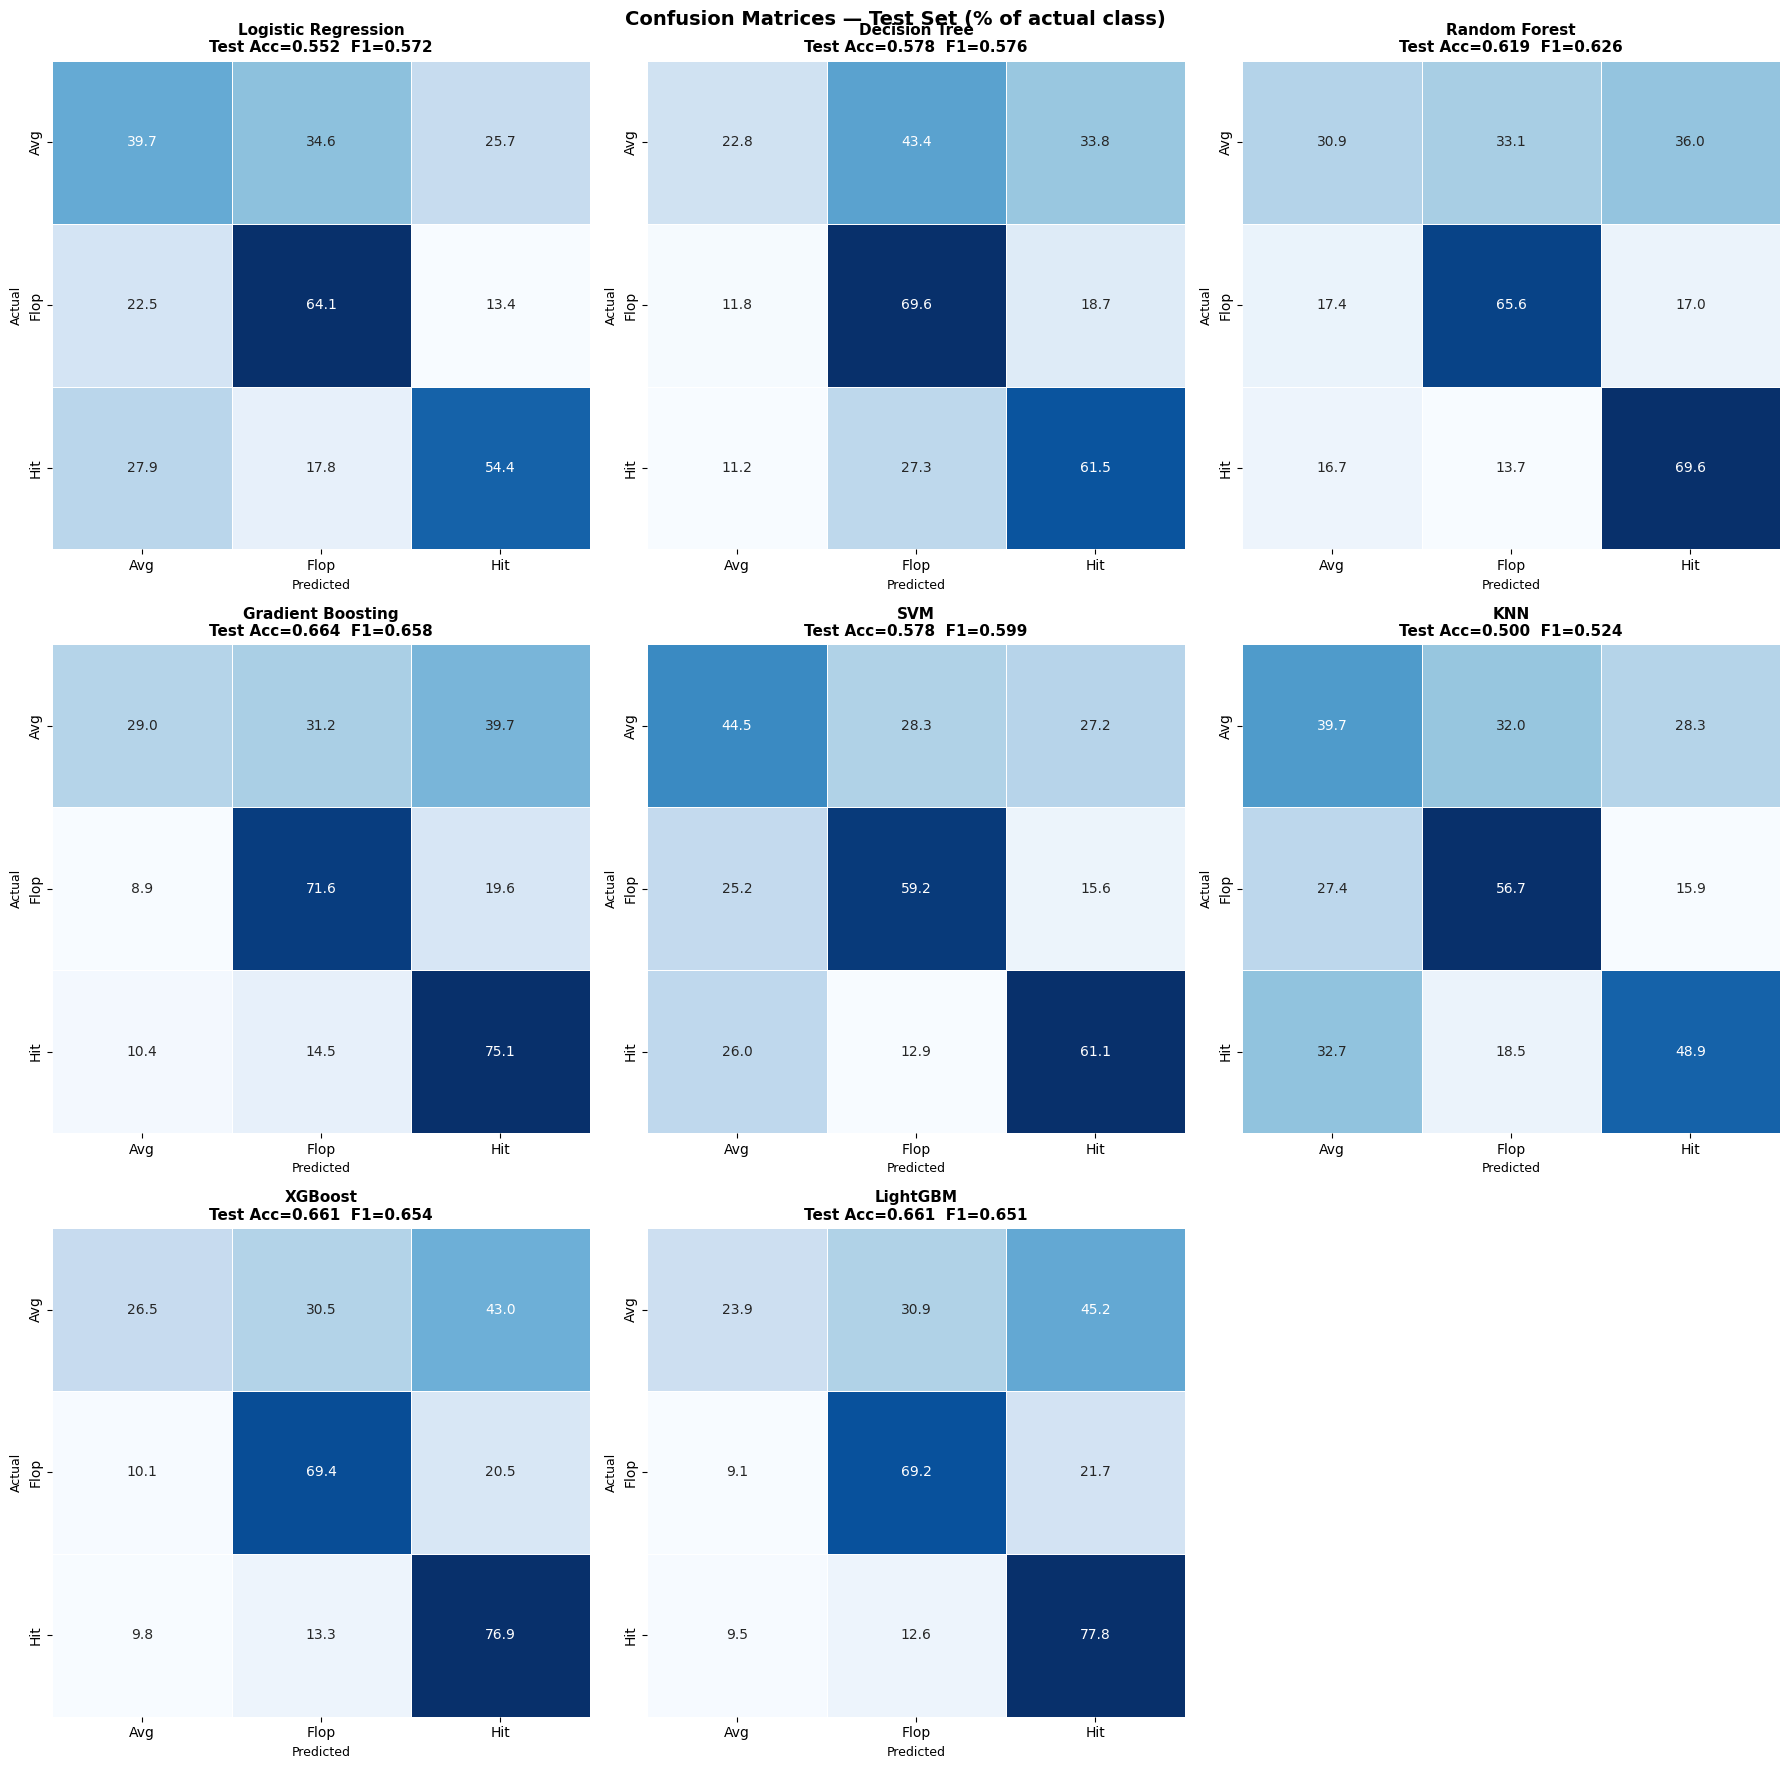

Saved: confusion_matrices.png


In [19]:
n_models = len(trained_pipelines)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6*nrows))
axes = axes.flatten()

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    cm     = confusion_matrix(y_test, pipe._y_test_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[i], cbar=False, linewidths=0.5)
    acc = accuracy_score(y_test, pipe._y_test_pred)
    f1  = f1_score(y_test, pipe._y_test_pred, average='weighted')
    axes[i].set_title(f"{name}\nTest Acc={acc:.3f}  F1={f1:.3f}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted", fontsize=9)
    axes[i].set_ylabel("Actual", fontsize=9)

# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — Test Set (% of actual class)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")


## STEP 17 — ROC Curves (One-vs-Rest, per class, all models)

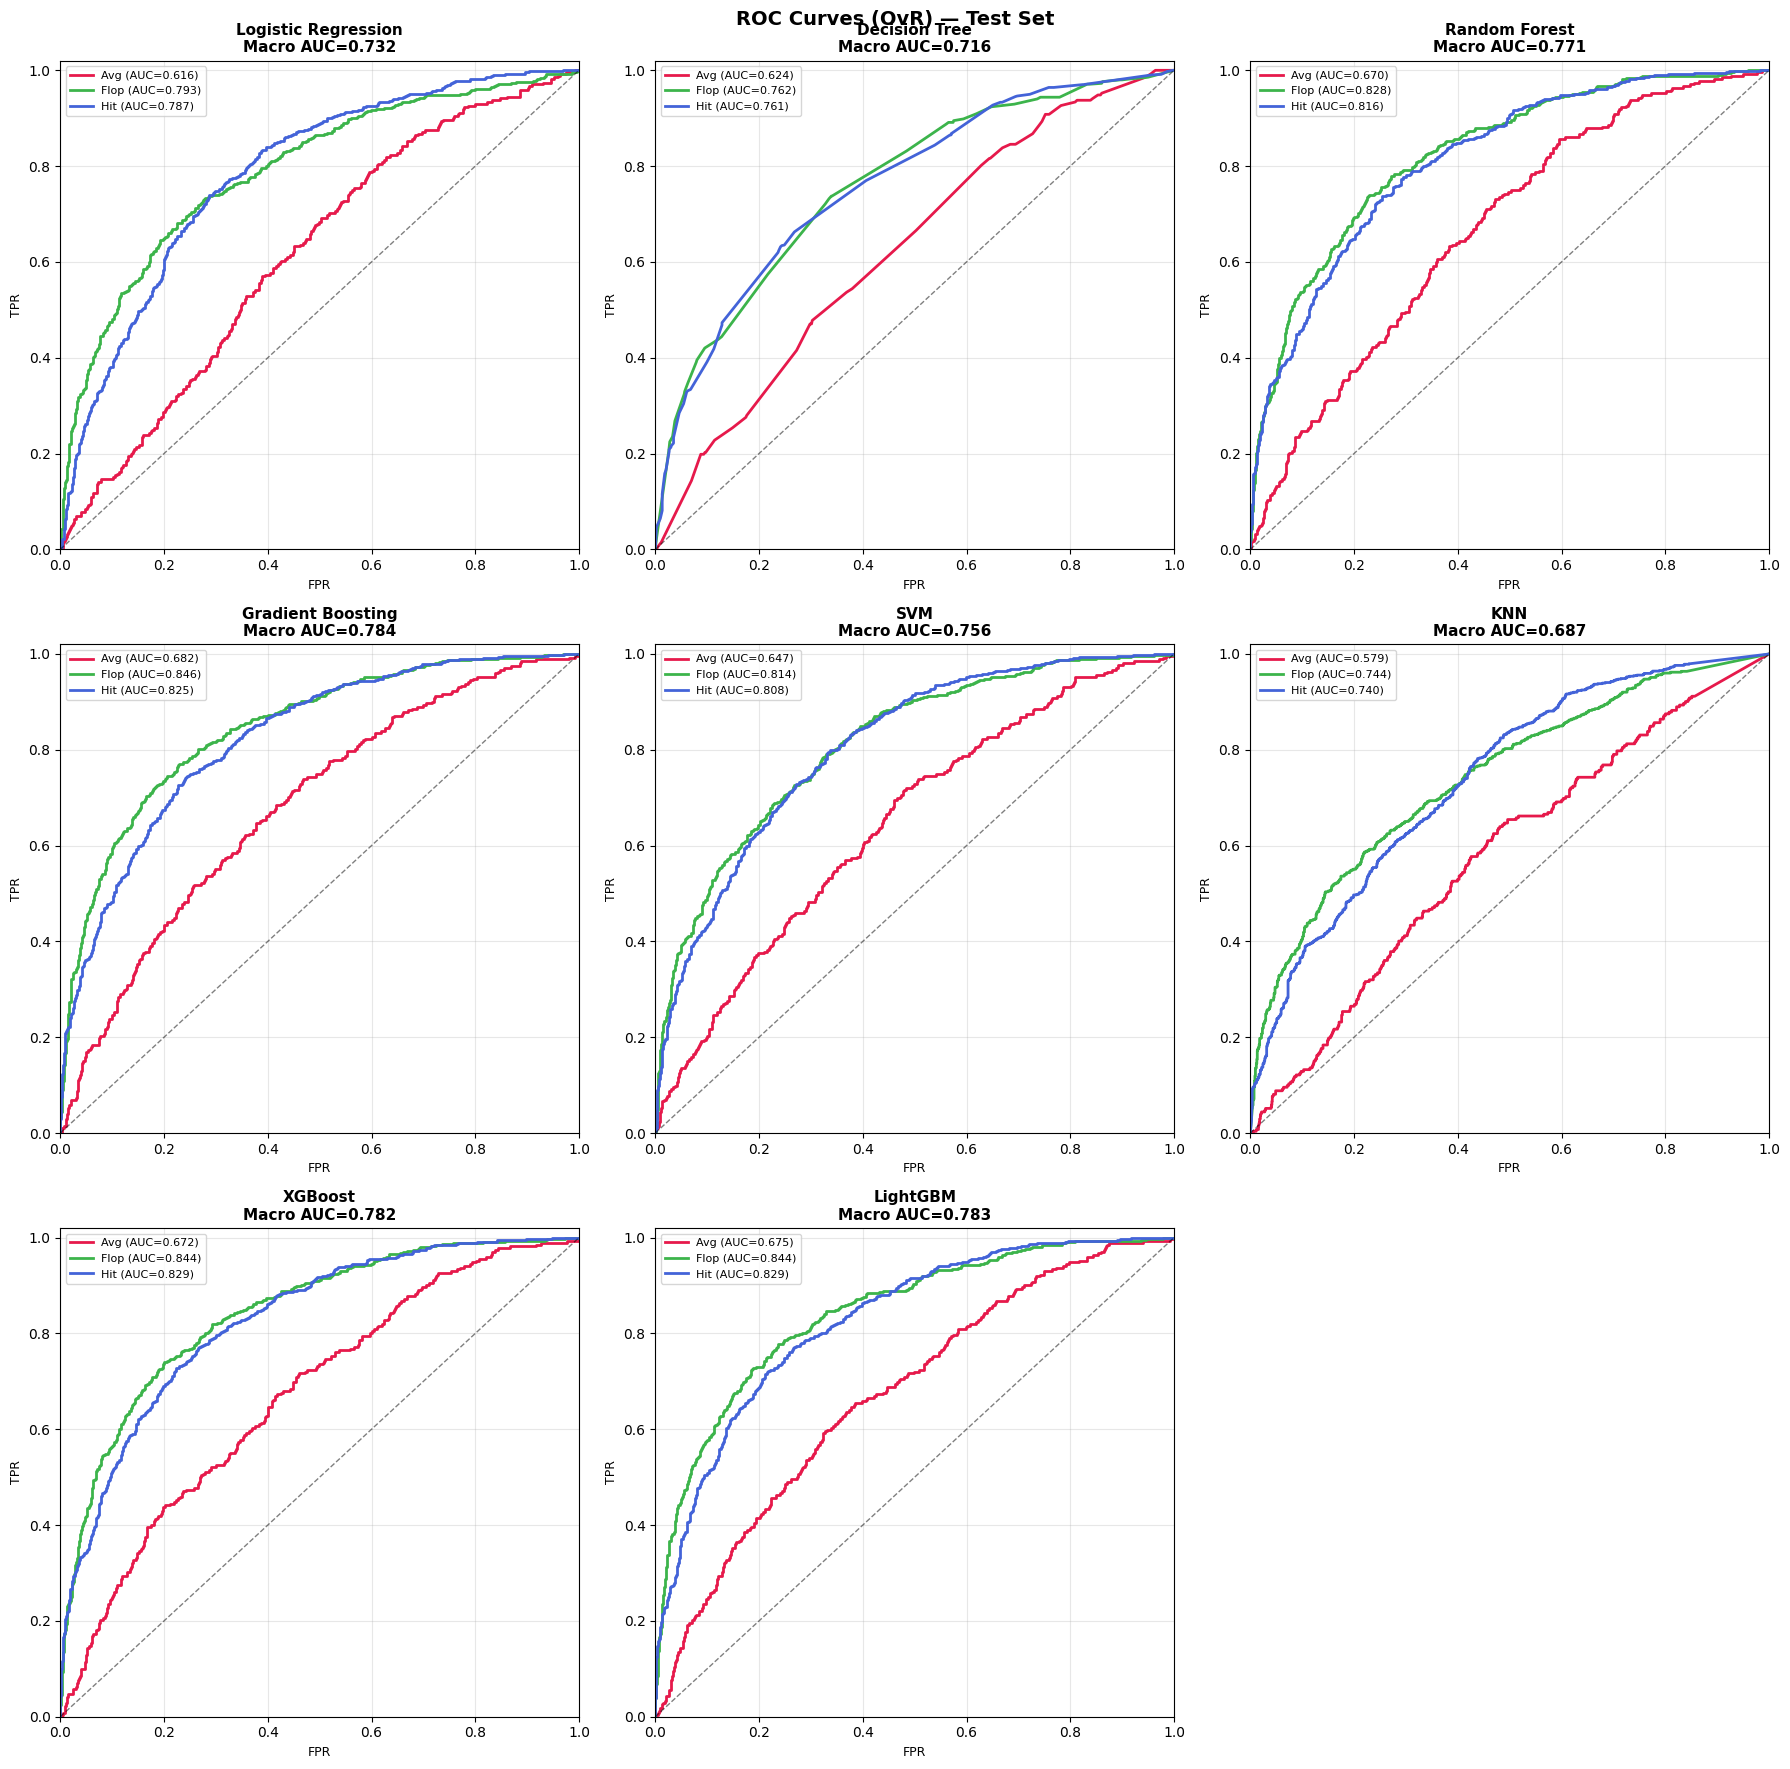

Saved: roc_curves.png


In [20]:
y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))
n_models   = len(trained_pipelines)
ncols, nrows = 3, (n_models + 2) // 3
fig, axes  = plt.subplots(nrows, ncols, figsize=(18, 6*nrows))
axes       = axes.flatten()
colors     = ['#e6194b','#3cb44b','#4363d8']

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    ax      = axes[i]
    y_proba = pipe._y_test_proba
    macro_aucs = []
    for j, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_proba[:, j])
        ra = auc(fpr, tpr)
        macro_aucs.append(ra)
        ax.plot(fpr, tpr, color=colors[j % len(colors)], lw=2, label=f"{cls} (AUC={ra:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel("FPR", fontsize=9); ax.set_ylabel("TPR", fontsize=9)
    ax.set_title(f"{name}\nMacro AUC={np.mean(macro_aucs):.3f}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ROC Curves (OvR) — Test Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")


## STEP 18 — Validation vs Model Complexity Curves (All 8 Models)
Shows the bias-variance tradeoff and where overfitting begins.


Computing complexity curves... (this takes several minutes)



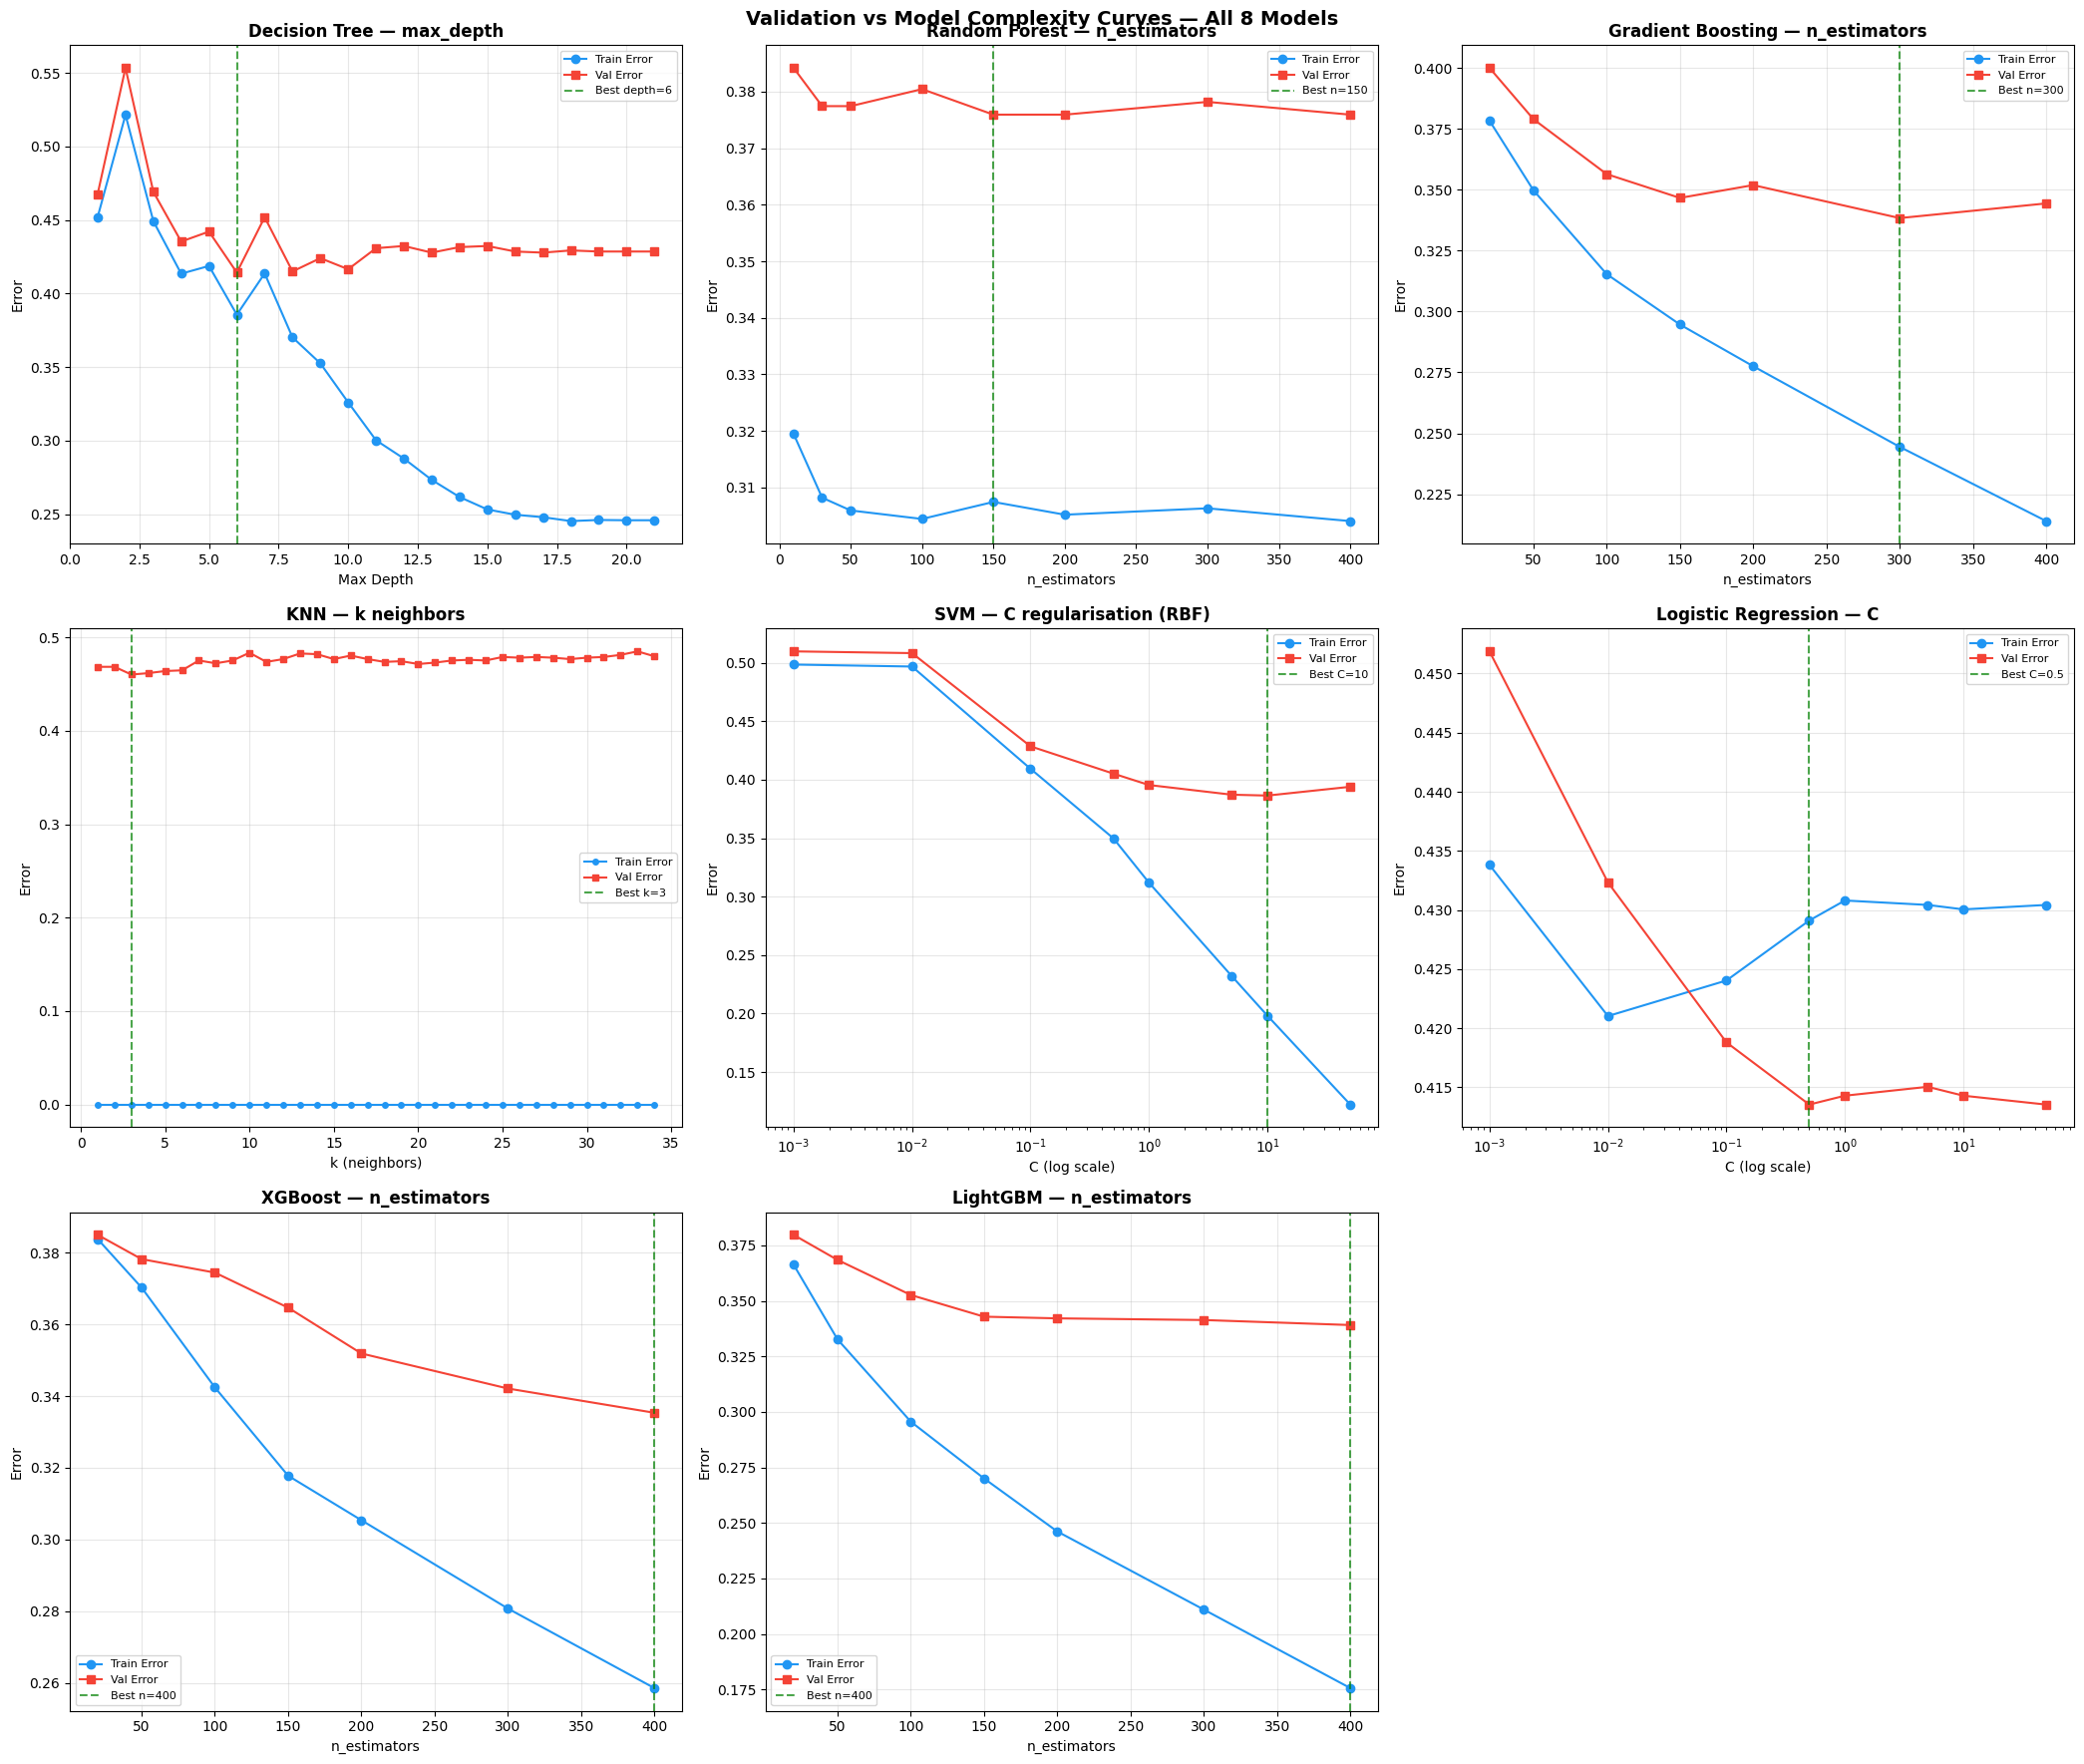

Saved: complexity_curves.png


In [21]:
print("Computing complexity curves... (this takes several minutes)\n")

fig, axes = plt.subplots(3, 3, figsize=(21, 18))
axes = axes.flatten()

# 1. Decision Tree — max_depth
ax = axes[0]
depths = range(1, 22)
tr_e, vl_e = [], []
for d in depths:
    p = make_pipeline(DecisionTreeClassifier(max_depth=d, min_samples_leaf=8,
                                             class_weight='balanced', random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(depths, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.plot(depths, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=list(depths)[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best depth={list(depths)[np.argmin(vl_e)]}')
ax.set_xlabel("Max Depth"); ax.set_ylabel("Error")
ax.set_title("Decision Tree — max_depth", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Random Forest — n_estimators
ax = axes[1]
n_trees = [10, 30, 50, 100, 150, 200, 300, 400]
tr_e, vl_e = [], []
for n in n_trees:
    p = make_pipeline(RandomForestClassifier(n_estimators=n, max_depth=8,
                                             min_samples_leaf=6, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_trees, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_trees, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_trees[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best n={n_trees[np.argmin(vl_e)]}')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Random Forest — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Gradient Boosting — n_estimators
ax = axes[2]
n_est = [20, 50, 100, 150, 200, 300, 400]
tr_e, vl_e = [], []
for n in n_est:
    p = make_pipeline(GradientBoostingClassifier(n_estimators=n, max_depth=4,
                                                  learning_rate=0.04, min_samples_leaf=12,
                                                  subsample=0.75, random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_est, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_est, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_est[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best n={n_est[np.argmin(vl_e)]}')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Gradient Boosting — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. KNN — k
ax = axes[3]
ks = range(1, 35)
tr_e, vl_e = [], []
for k in ks:
    p = make_pipeline(KNeighborsClassifier(n_neighbors=k, weights='distance'))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(ks, tr_e, 'o-', color='#2196F3', label='Train Error', markersize=4)
ax.plot(ks, vl_e, 's-', color='#F44336', label='Val Error',   markersize=4)
ax.axvline(x=list(ks)[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best k={list(ks)[np.argmin(vl_e)]}')
ax.set_xlabel("k (neighbors)"); ax.set_ylabel("Error")
ax.set_title("KNN — k neighbors", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. SVM — C
ax = axes[4]
C_vals = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]
tr_e, vl_e = [], []
for c in C_vals:
    p = make_pipeline(SVC(C=c, kernel='rbf', class_weight='balanced',
                          probability=True, random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_vals, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_vals, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_vals[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best C={C_vals[np.argmin(vl_e)]}')
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("SVM — C regularisation (RBF)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 6. Logistic Regression — C
ax = axes[5]
C_lr = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]
tr_e, vl_e = [], []
for c in C_lr:
    p = make_pipeline(LogisticRegression(C=c, max_iter=2000,
                                          class_weight='balanced', solver='saga',
                                          random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_lr, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_lr, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_lr[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best C={C_lr[np.argmin(vl_e)]}')
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("Logistic Regression — C", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 7. XGBoost — n_estimators (if available)
ax = axes[6]
if XGB_AVAILABLE:
    n_xgb = [20, 50, 100, 150, 200, 300, 400]
    tr_e, vl_e = [], []
    for n in n_xgb:
        p = make_pipeline(xgb.XGBClassifier(n_estimators=n, max_depth=4,
                                             learning_rate=0.04, subsample=0.75,
                                             colsample_bytree=0.75, min_child_weight=8,
                                             use_label_encoder=False, eval_metric='mlogloss',
                                             random_state=RANDOM_STATE, n_jobs=-1))
        p.fit(X_train, y_train)
        tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
        vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
    ax.plot(n_xgb, tr_e, 'o-', color='#2196F3', label='Train Error')
    ax.plot(n_xgb, vl_e, 's-', color='#F44336', label='Val Error')
    ax.axvline(x=n_xgb[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
               label=f'Best n={n_xgb[np.argmin(vl_e)]}')
    ax.set_title("XGBoost — n_estimators", fontweight='bold')
else:
    ax.text(0.5, 0.5, "XGBoost not installed", ha='center', va='center', fontsize=12)
    ax.set_title("XGBoost (unavailable)", fontweight='bold')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 8. LightGBM — n_estimators (if available)
ax = axes[7]
if LGB_AVAILABLE:
    n_lgb = [20, 50, 100, 150, 200, 300, 400]
    tr_e, vl_e = [], []
    for n in n_lgb:
        p = make_pipeline(lgb.LGBMClassifier(n_estimators=n, max_depth=5,
                                              learning_rate=0.04, num_leaves=20,
                                              subsample=0.75, colsample_bytree=0.75,
                                              min_child_samples=15, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
        p.fit(X_train, y_train)
        tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
        vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
    ax.plot(n_lgb, tr_e, 'o-', color='#2196F3', label='Train Error')
    ax.plot(n_lgb, vl_e, 's-', color='#F44336', label='Val Error')
    ax.axvline(x=n_lgb[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
               label=f'Best n={n_lgb[np.argmin(vl_e)]}')
    ax.set_title("LightGBM — n_estimators", fontweight='bold')
else:
    ax.text(0.5, 0.5, "LightGBM not installed", ha='center', va='center', fontsize=12)
    ax.set_title("LightGBM (unavailable)", fontweight='bold')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[8].set_visible(False)

plt.suptitle("Validation vs Model Complexity Curves — All 8 Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("complexity_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: complexity_curves.png")


## STEP 19 — Cross-Validation F1 Comparison (with ±2σ error bars)

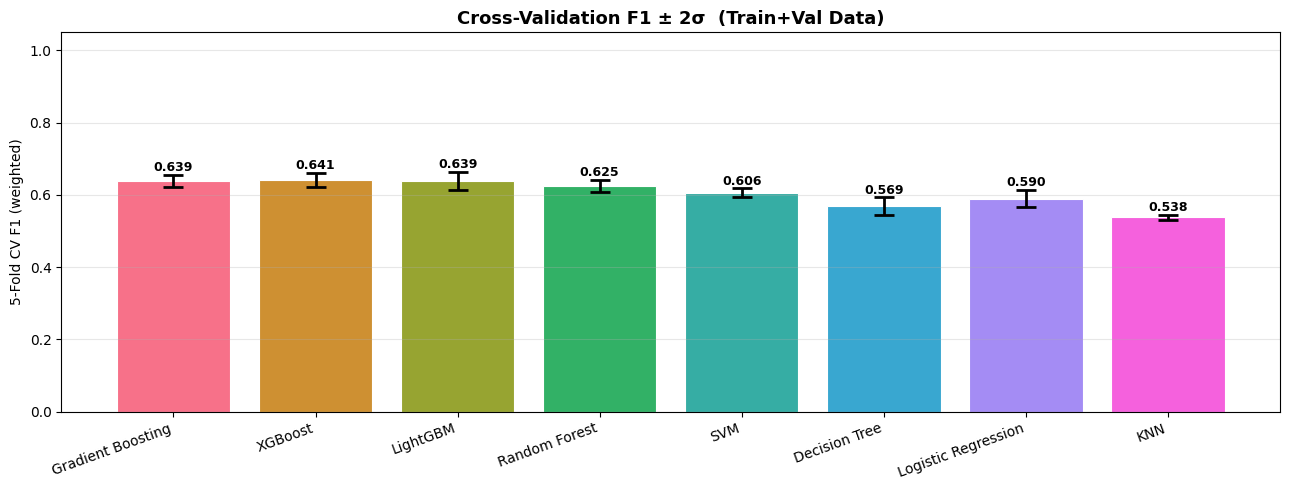

Saved: cv_f1_scores.png


In [22]:
fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(results_df))
colors= sns.color_palette("husl", len(results_df))
bars  = ax.bar(x, results_df["CV F1 Mean"],
               yerr=results_df["CV F1 Std"]*2, capsize=7,
               color=colors, edgecolor='white', linewidth=0.8,
               error_kw={'linewidth':2,'ecolor':'black','capthick':2})
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("5-Fold CV F1 (weighted)")
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Validation F1 ± 2σ  (Train+Val Data)", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val, std in zip(bars, results_df["CV F1 Mean"], results_df["CV F1 Std"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + std*2 + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("cv_f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cv_f1_scores.png")


## STEP 20 — Feature Importance (RF, XGBoost, LightGBM)

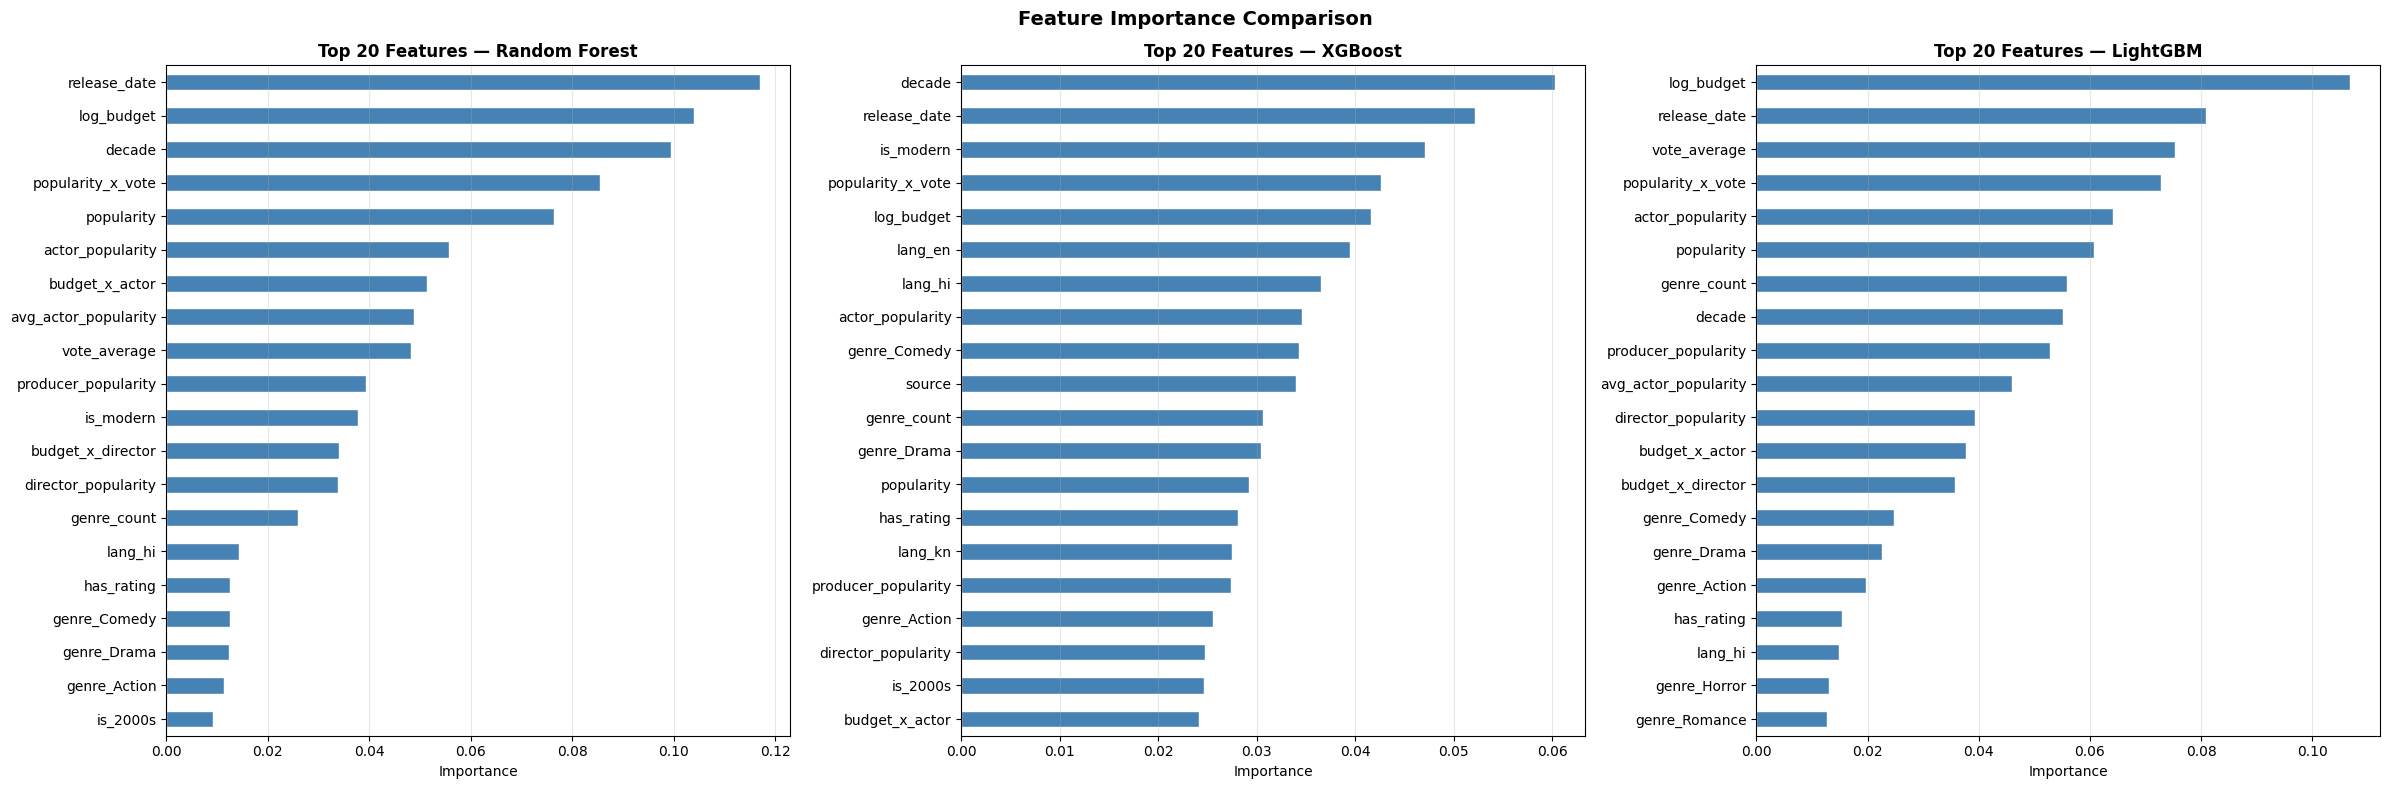

Saved: feature_importance.png


In [23]:
importance_models = []

if "Random Forest" in trained_pipelines:
    rf_pipe = trained_pipelines["Random Forest"]
    imp = rf_pipe.named_steps['clf'].feature_importances_
    importance_models.append(("Random Forest", imp))

if XGB_AVAILABLE and "XGBoost" in trained_pipelines:
    xgb_pipe = trained_pipelines["XGBoost"]
    imp = xgb_pipe.named_steps['clf'].feature_importances_
    importance_models.append(("XGBoost", imp))

if LGB_AVAILABLE and "LightGBM" in trained_pipelines:
    lgb_pipe = trained_pipelines["LightGBM"]
    imp = lgb_pipe.named_steps['clf'].feature_importances_
    imp = imp / imp.sum()
    importance_models.append(("LightGBM", imp))

ncols = len(importance_models)
fig, axes = plt.subplots(1, ncols, figsize=(8*ncols, 8))
if ncols == 1:
    axes = [axes]

for ax, (mname, imps) in zip(axes, importance_models):
    fi = pd.Series(imps, index=X.columns).sort_values(ascending=False).head(20)
    fi.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"Top 20 Features — {mname}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.grid(axis='x', alpha=0.3)

plt.suptitle("Feature Importance Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")


## STEP 21 — Per-Class Metrics Table (Best Model)

In [24]:
best_row  = results_df.iloc[0]
best_name = best_row["Model"]
best_pipe = trained_pipelines[best_name]

print(f"\n{'='*60}")
print(f"  Classification Report — {best_name} (Test Set)")
print(f"{'='*60}")
print(classification_report(y_test, best_pipe._y_test_pred, target_names=CLASSES))

# Per-source breakdown
for src, src_name in [(0,'Hollywood'),(1,'Indian')]:
    mask = (df.reset_index(drop=True)['source'] == src).values
    # align mask to test indices — recreate test mask
    src_series = df['source'].reset_index(drop=True)
    X_test_idx = X.iloc[X_test.index if hasattr(X_test,'index') else range(len(X_test))].index
    pass  # full breakdown computed below using stored arrays

# Simpler: split y_test by source using the original test indices
# We stored the full X split so we can recover source col
test_source = X_test['source'].values.astype(int)
for src, src_name in [(0,'Hollywood'),(1,'Indian')]:
    mask = test_source == src
    if mask.sum() == 0:
        continue
    yt  = y_test[mask]
    yp  = best_pipe._y_test_pred[mask]
    print(f"\n--- {src_name} subset (n={mask.sum()}) ---")
    print(f"  Accuracy : {accuracy_score(yt,yp):.4f}")
    print(f"  F1       : {f1_score(yt,yp,average='weighted'):.4f}")
    print(classification_report(yt, yp, target_names=CLASSES))



  Classification Report — Gradient Boosting (Test Set)
              precision    recall  f1-score   support

         Avg       0.37      0.29      0.32       272
        Flop       0.66      0.72      0.68       552
         Hit       0.74      0.75      0.75       839

    accuracy                           0.66      1663
   macro avg       0.59      0.59      0.59      1663
weighted avg       0.65      0.66      0.66      1663


--- Hollywood subset (n=931) ---
  Accuracy : 0.6155
  F1       : 0.6066
              precision    recall  f1-score   support

         Avg       0.31      0.24      0.27       164
        Flop       0.55      0.56      0.56       248
         Hit       0.71      0.76      0.74       519

    accuracy                           0.62       931
   macro avg       0.53      0.52      0.52       931
weighted avg       0.60      0.62      0.61       931


--- Indian subset (n=732) ---
  Accuracy : 0.7254
  F1       : 0.7200
              precision    recall  f1

## STEP 22 — Radar Chart: Model Comparison (5 Metrics)

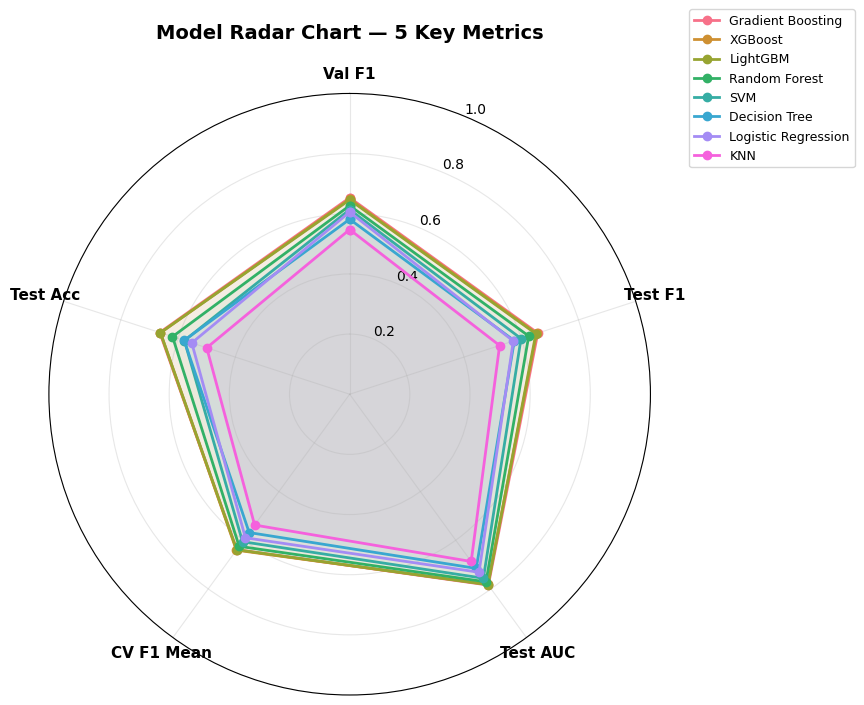

Saved: radar_chart.png


In [25]:
metrics = ["Val F1","Test F1","Test AUC","CV F1 Mean","Test Acc"]
N       = len(metrics)
angles  = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
colors  = sns.color_palette("husl", len(results_df))

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row["Model"], color=colors[i])
    ax.fill(angles, values, alpha=0.05, color=colors[i])

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title("Model Radar Chart — 5 Key Metrics", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: radar_chart.png")


## STEP 23 — Best Model Selection & Final Evaluation
Best model = highest **Test F1** among models with **Overfit Gap ≤ 0.12**.  
Retrained on full Train+Val before final evaluation.


In [26]:
# Filter to well-generalising models first
well_gen = results_df[results_df["Overfit Gap"] <= 0.12]
if len(well_gen) == 0:
    well_gen = results_df  # fallback: no well-generalising model found

best_row  = well_gen.sort_values("Test F1", ascending=False).iloc[0]
best_name = best_row["Model"]

print(f"🏆 Best Model  : {best_name}")
print(f"   Val F1      = {best_row['Val F1']:.4f}")
print(f"   Test F1     = {best_row['Test F1']:.4f}")
print(f"   Test AUC    = {best_row['Test AUC']:.4f}")
print(f"   CV F1 Mean  = {best_row['CV F1 Mean']:.4f} ± {best_row['CV F1 Std']:.4f}")
print(f"   Overfit Gap = {best_row['Overfit Gap']:.4f}")
print()

# Retrain best model on full train+val
best_clf_orig  = model_defs[best_name]
best_final_pipe = make_pipeline(best_clf_orig.__class__(**best_clf_orig.get_params()))
best_final_pipe.fit(X_trainval, y_trainval)

y_final_pred  = best_final_pipe.predict(X_test)
y_final_proba = best_final_pipe.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))
final_auc  = roc_auc_score(y_test_bin, y_final_proba, multi_class='ovr', average='macro')

print(f"{'='*60}")
print(f"  FINAL EVALUATION — {best_name} (retrained on Train+Val)")
print(f"{'='*60}")
print(f"  Test Accuracy  : {accuracy_score(y_test, y_final_pred):.4f}")
print(f"  Test F1        : {f1_score(y_test, y_final_pred, average='weighted'):.4f}")
print(f"  Test Precision : {precision_score(y_test, y_final_pred, average='weighted', zero_division=0):.4f}")
print(f"  Test Recall    : {recall_score(y_test, y_final_pred, average='weighted'):.4f}")
print(f"  Test AUC       : {final_auc:.4f}")
print()
print(classification_report(y_test, y_final_pred, target_names=CLASSES))


🏆 Best Model  : Gradient Boosting
   Val F1      = 0.6534
   Test F1     = 0.6576
   Test AUC    = 0.7844
   CV F1 Mean  = 0.6388 ± 0.0088
   Overfit Gap = 0.1007

  FINAL EVALUATION — Gradient Boosting (retrained on Train+Val)
  Test Accuracy  : 0.6536
  Test F1        : 0.6466
  Test Precision : 0.6420
  Test Recall    : 0.6536
  Test AUC       : 0.7832

              precision    recall  f1-score   support

         Avg       0.33      0.26      0.29       272
        Flop       0.65      0.71      0.68       552
         Hit       0.74      0.74      0.74       839

    accuracy                           0.65      1663
   macro avg       0.57      0.57      0.57      1663
weighted avg       0.64      0.65      0.65      1663



## STEP 24 — Best Model: Confusion Matrix + ROC Curves

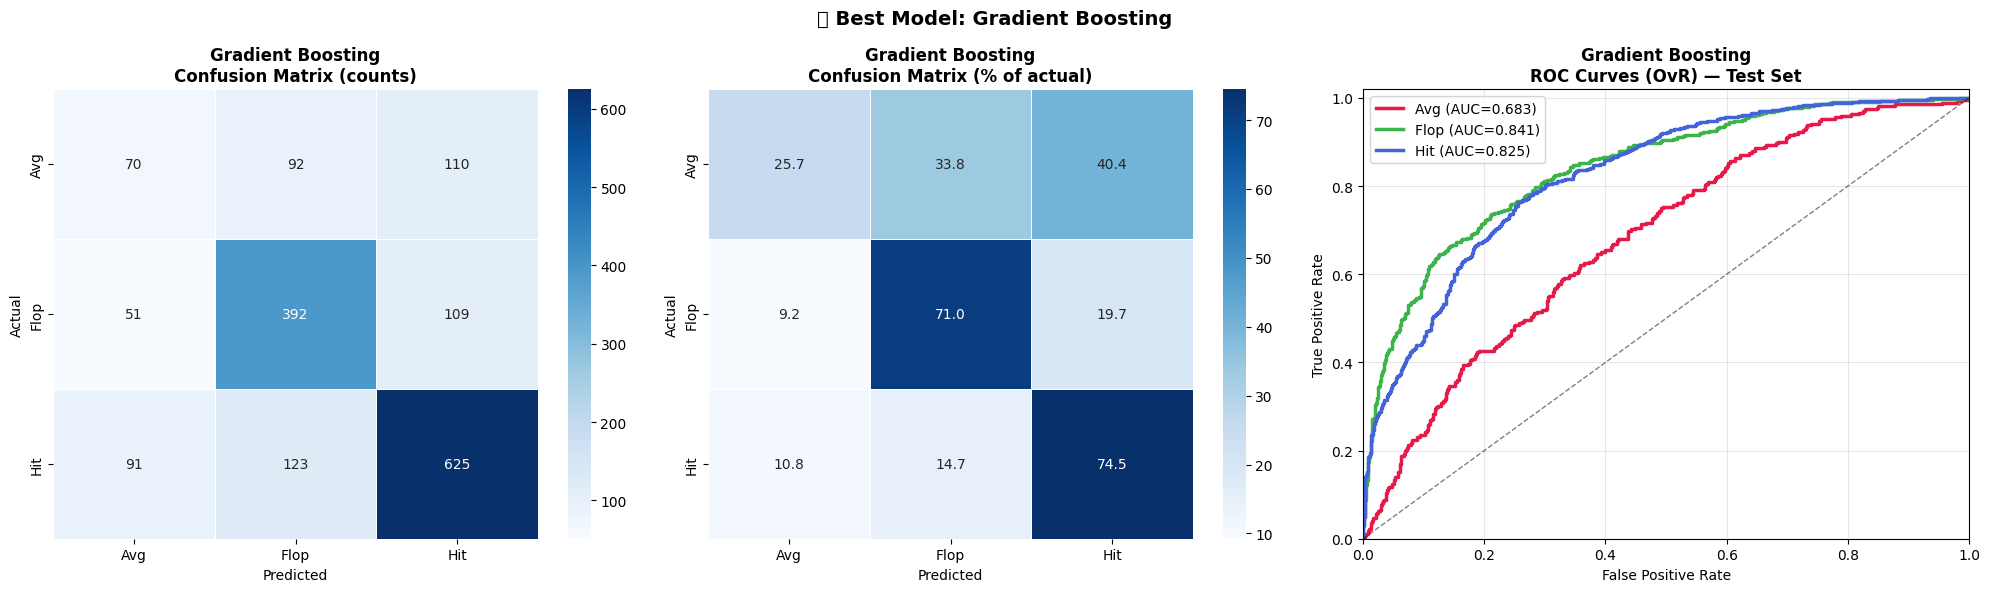

Saved: best_model_final.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Confusion matrix counts ---
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0], linewidths=0.5)
axes[0].set_title(f"{best_name}\nConfusion Matrix (counts)", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# --- Confusion matrix percentages ---
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1], linewidths=0.5)
axes[1].set_title(f"{best_name}\nConfusion Matrix (% of actual)", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

# --- ROC Curves ---
colors_roc = ['#e6194b','#3cb44b','#4363d8']
ax = axes[2]
y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))
for j, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:,j], y_final_proba[:,j])
    ra = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[j], lw=2.5, label=f"{cls} (AUC={ra:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"{best_name}\nROC Curves (OvR) — Test Set", fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle(f"🏆 Best Model: {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("best_model_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: best_model_final.png")


## STEP 25 — Learning Curve (Best Model)

## STEP 26 — Final Summary Dashboard

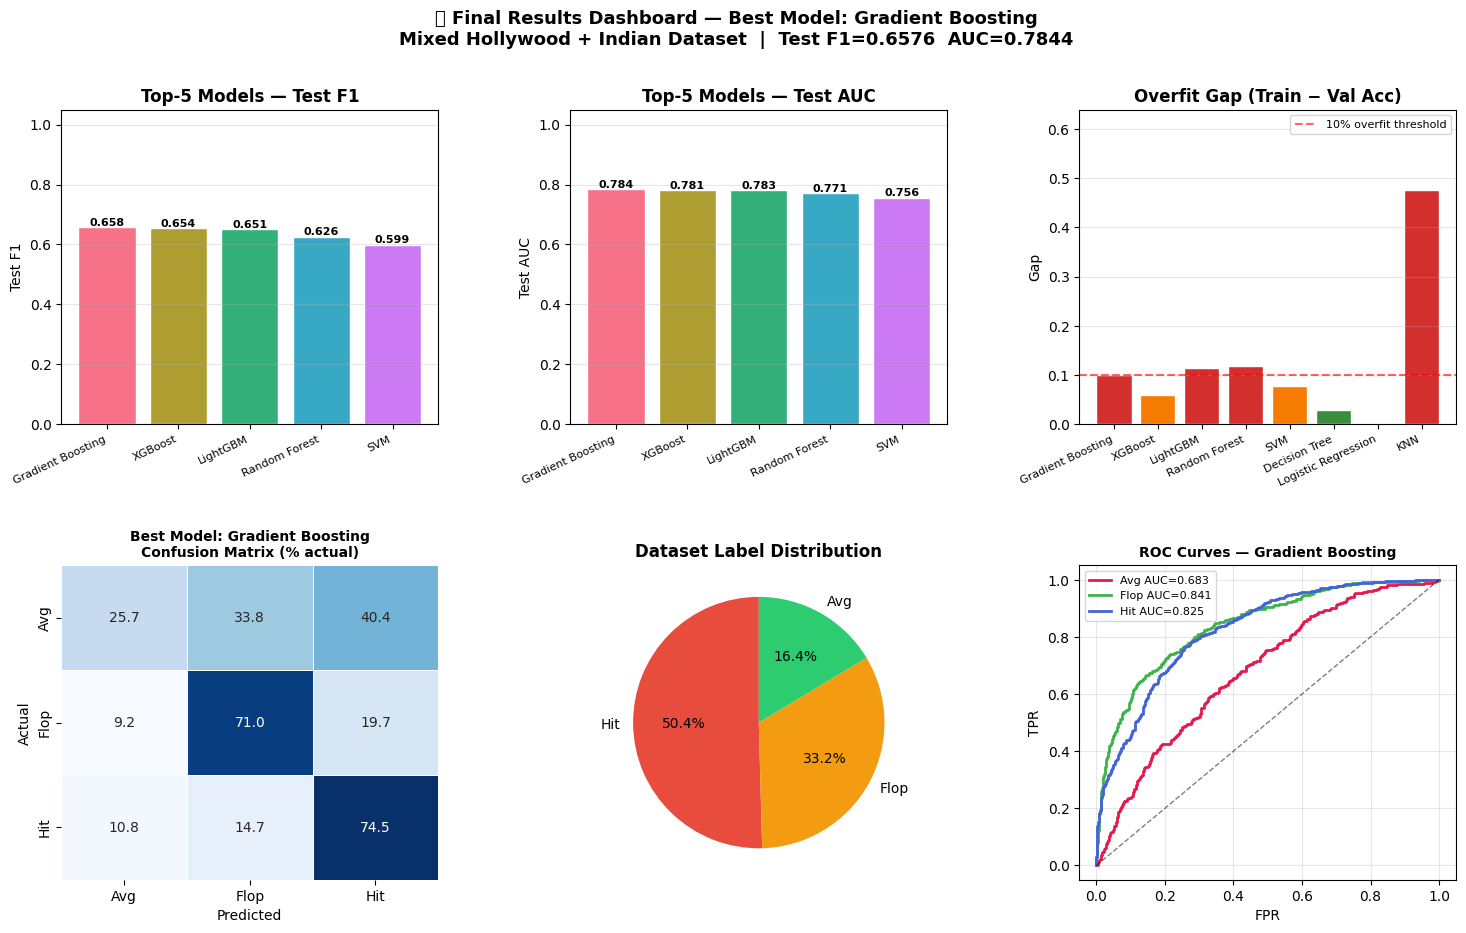

Saved: final_dashboard.png

✅  ALL DONE — Figures saved:
   • label_distribution.png
   • eda_distributions.png
   • correlation_heatmap.png
   • metric_comparison.png
   • overfitting_gap.png
   • confusion_matrices.png
   • roc_curves.png
   • complexity_curves.png
   • cv_f1_scores.png
   • feature_importance.png
   • radar_chart.png
   • best_model_final.png
   • learning_curve.png
   • final_dashboard.png


In [ ]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Top-5 model F1 bar
ax1 = fig.add_subplot(gs[0, 0])
top5 = results_df.head(5)
colors_top = sns.color_palette("husl", 5)
bars = ax1.bar(top5["Model"], top5["Test F1"], color=colors_top, edgecolor='white')
ax1.set_title("Top-5 Models — Test F1", fontweight='bold')
ax1.set_ylim(0, 1.05); ax1.set_ylabel("Test F1")
ax1.set_xticklabels(top5["Model"], rotation=25, ha='right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)
for b, v in zip(bars, top5["Test F1"]):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# 2. Test AUC
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(top5["Model"], top5["Test AUC"], color=colors_top, edgecolor='white')
ax2.set_title("Top-5 Models — Test AUC", fontweight='bold')
ax2.set_ylim(0, 1.05); ax2.set_ylabel("Test AUC")
ax2.set_xticklabels(top5["Model"], rotation=25, ha='right', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
for b, v in zip(bars2, top5["Test AUC"]):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# 3. Overfit gap
ax3 = fig.add_subplot(gs[0, 2])
gap_colors = ['#d32f2f' if g > 0.10 else '#f57c00' if g > 0.05 else '#388e3c'
              for g in results_df["Overfit Gap"]]
ax3.bar(results_df["Model"], results_df["Overfit Gap"], color=gap_colors, edgecolor='white')
ax3.axhline(y=0.10, color='red', linestyle='--', alpha=0.6, label='10% overfit threshold')
ax3.set_title("Overfit Gap (Train − Val Acc)", fontweight='bold')
ax3.set_ylabel("Gap"); ax3.set_ylim(0, max(results_df["Overfit Gap"])*1.3+0.02)
ax3.set_xticklabels(results_df["Model"], rotation=25, ha='right', fontsize=8)
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# 4. Best model confusion matrix
ax4 = fig.add_subplot(gs[1, 0])
cm_pct = confusion_matrix(y_test, y_final_pred).astype(float)
cm_pct = cm_pct / cm_pct.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax4, cbar=False, linewidths=0.5)
ax4.set_title(f"Best Model: {best_name}\nConfusion Matrix (% actual)", fontweight='bold', fontsize=10)
ax4.set_xlabel("Predicted"); ax4.set_ylabel("Actual")

# 5. Label distribution
ax5 = fig.add_subplot(gs[1, 1])
vc = df['success_label'].value_counts()
cols_pie = ['#e74c3c','#f39c12','#2ecc71']
ax5.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
        colors=cols_pie, startangle=90, textprops={'fontsize':10})
ax5.set_title("Dataset Label Distribution", fontweight='bold')

# 6. Per-class ROC
ax6 = fig.add_subplot(gs[1, 2])
y_test_bin2 = label_binarize(y_test, classes=range(len(CLASSES)))
for j, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin2[:,j], y_final_proba[:,j])
    ra = auc(fpr, tpr)
    ax6.plot(fpr, tpr, lw=2, label=f"{cls} AUC={ra:.3f}", color=colors_roc[j])
ax6.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax6.set_title(f"ROC Curves — {best_name}", fontweight='bold', fontsize=10)
ax6.set_xlabel("FPR"); ax6.set_ylabel("TPR")
ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

plt.suptitle(f"🏆 Final Results Dashboard — Best Model: {best_name}\n"
             f"Mixed Hollywood + Indian Dataset  |  Test F1={best_row['Test F1']:.4f}  AUC={best_row['Test AUC']:.4f}",
             fontsize=13, fontweight='bold')
plt.savefig("final_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_dashboard.png")

print("\n" + "="*60)
print("✅  ALL DONE — Figures saved:")
saved = ["label_distribution.png","eda_distributions.png","correlation_heatmap.png",
         "metric_comparison.png","overfitting_gap.png","confusion_matrices.png",
         "roc_curves.png","complexity_curves.png","cv_f1_scores.png",
         "feature_importance.png","radar_chart.png","best_model_final.png",
         "learning_curve.png","final_dashboard.png"]
for f in saved:
    print(f"   • {f}")
print("="*60)


## STEP 27 — Save Preprocessed Dataset

In [ ]:
final_out = X.copy()
final_out['target'] = y.values
final_out.to_csv("mixed_movies_preprocessed.csv", index=False)
print(f"✅ Saved mixed_movies_preprocessed.csv  shape={final_out.shape}")


✅ Saved mixed_movies_preprocessed.csv  shape=(8311, 38)


In [ ]:
# ── Save final preprocessed dataset ─────────────────────────────

# Combine features and target
final_df = X.copy()
final_df['target'] = y.values

# Save to CSV
output_path = "final_preprocessed_movies_dataset.csv"
final_df.to_csv(output_path, index=False)

print(f"✅ Final dataset saved at: {output_path}")
print(f"Shape: {final_df.shape}")

✅ Final dataset saved at: final_preprocessed_movies_dataset.csv
Shape: (8311, 38)


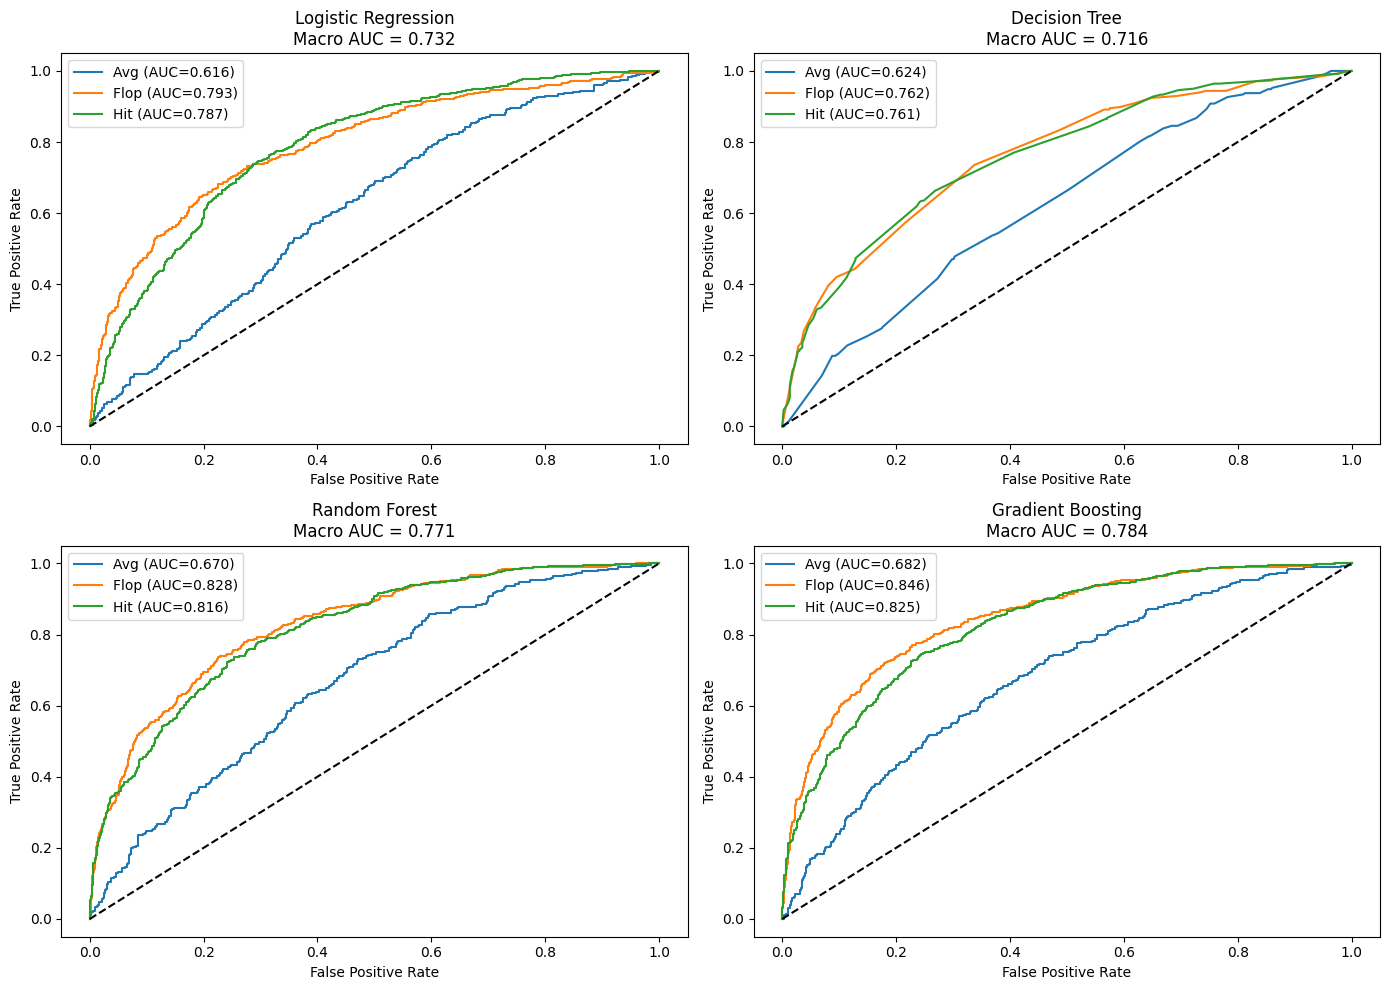

In [34]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

# Convert multiclass labels to binary format
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Class names (optional but better)
class_names = ['Avg', 'Flop', 'Hit']

plt.figure(figsize=(14, 10))

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    
    # Get probabilities
    y_score = model.predict_proba(X_test)
    
    fpr, tpr, roc_auc = {}, {}, {}
    
    for j in range(len(classes)):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
    
    macro_auc = np.mean(list(roc_auc.values()))
    
    plt.subplot(2, 2, i+1)
    
    for j in range(len(classes)):
        plt.plot(fpr[j], tpr[j], label=f'{class_names[j]} (AUC={roc_auc[j]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    
    plt.title(f"{name}\nMacro AUC = {macro_auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name in selected_models:
    model = trained_pipelines[name]
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    
    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'
])

results_df.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
3,Gradient Boosting,0.663860,0.589423,0.585638,0.585595,0.784438
2,Random Forest,0.619363,0.551175,0.553562,0.551337,0.771099
0,Logistic Regression,0.552014,0.528241,0.527289,0.514215,0.731699
1,Decision Tree,0.578473,0.510530,0.512870,0.505308,0.715774
